In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
out_dir = '.'

# Every (device, variant) combination produced by submit.sh.
DATASETS = [
    'cpu',
    'gpu_h200_nocmdbuf',        # XLA default command buffers (FUSION, CUBLAS, ...)
    'gpu_h200_cmdbuf',          # ... plus +WHILE,+CONDITIONAL (Tsit5 loop as one CUDA graph)
    'gpu_h200_all_cmdbuf_off',  # FUSION only: cuBLAS not graph-captured
    'gpu_h200_ozaki',           # FUSION only + cuBLAS FP64 emulation
    'gpu_b200_all_cmdbuf_off',
    'gpu_b200_ozaki',
]

# Format: (marker, color, label)
SOLVERS = ['dq_basic', 'cayley']
solver_style = {
    'dq_basic': ('s', '#2a78d6', 'Basic (Dynamiqs)'),
    'cayley'  : ('^', '#008300', 'Cayley (Dynamiqs)')
}

# One authoritative file per (device, variant): out/<name>.npy, exactly what
# consolidate.py writes. Each row carries its own `kernels` summary, so no trace
# files are read here. Anything re-consolidated shows up immediately.
data = {}
for ds in DATASETS:
    path = f'{out_dir}/{ds}.npy'
    if os.path.exists(path):
        data[ds] = np.load(path, allow_pickle=True).item()
    else:
        print(f'  (missing, skipped: {path})')
devices = list(data)

# Print what was loaded. If a sweep was extended and the numbers below do not
# reflect it, re-run consolidate.py rather than hunting in the plots.
for ds in devices:
    dims = sorted({d for s in data[ds] for d in data[ds][s]})
    n = sum(len(v) for s in data[ds] for v in data[ds][s].values())
    nk = sum(1 for s in data[ds] for v in data[ds][s].values() for r in v if r.get('kernels'))
    print(f'  {ds:26s} {n:4d} rows, {nk:4d} with kernel detail, d = {dims[0]}..{dims[-1]}')

  cpu                         220 rows,    0 with kernel detail, d = 2..2048
  gpu_h200_nocmdbuf           280 rows,  280 with kernel detail, d = 2..16384
  gpu_h200_cmdbuf             240 rows,  240 with kernel detail, d = 2..4096
  gpu_h200_all_cmdbuf_off     280 rows,  280 with kernel detail, d = 2..16384
  gpu_h200_ozaki              240 rows,  240 with kernel detail, d = 2..4096
  gpu_b200_all_cmdbuf_off     240 rows,  240 with kernel detail, d = 2..4096
  gpu_b200_ozaki              240 rows,  240 with kernel detail, d = 2..4096


In [3]:
def collect(data_for_method, key='', avg_type='median', breakdown=False):
    """ Collect stats for a given key. """
    if not key:
        return np.array([]), np.array([]), np.array([])

    dims = sorted(data_for_method.keys())
    avg_func = np.median if avg_type == 'median' else np.mean
    valid_dims, avgs, all_values = [], [], []
    
    for d in dims:
        # skip dims that don't have any data
        if d not in data_for_method:
            continue

        # Get the values
        if breakdown:
            vals = [row['op_self_ns'][key] for row in data_for_method[d]]
        else:
            vals = [row[key] for row in data_for_method[d]]
        valid_dims.append(d)
        avgs.append(avg_func(vals))
        all_values.append(vals)
    return np.array(valid_dims), np.array(avgs), np.array(all_values)

def collect_breakdown(data_for_method, avg_type='mean', top_n=7):
    """ Collect stats for all keys in the 'op_self_ns' breakdown. """
    
    dims = sorted(data_for_method.keys())
    
    per_dim = []
    totals = {}
    for d in dims:
        rows = data_for_method[d]
        
        # go through all the runs (time stored in ms)
        mean_wall_time = {}
        for r in rows:
            for op, time in r['op_self_ns'].items():
                op_key = re.sub(r'\.\d+$', '', op)
                mean_wall_time[op_key] = mean_wall_time.get(op_key, 0.0) + time / len(rows) / 1e6
        per_dim.append(mean_wall_time)
        
        # add up the time across dimensions
        for op_key, time in mean_wall_time.items():
            totals[op_key] = totals.get(op_key, 0.0) + time

    # get the top_n operations by total time
    top = [op for op, _ in sorted(totals.items(), key=lambda kv: kv[1], reverse=True)[:top_n]]

    # essentially, transpose to get time vs. dim for each op
    table = {op: np.array([d.get(op, 0.0) for d in per_dim]) for op in top}

    # get the "other" category, which is the sum of all ops not in the top_n
    table['other'] = np.array([sum(v for k, v in d.items() if k not in top) for d in per_dim])

    return dims, table

def any_row_has_key(runs_by_method, key):
    return any(
        key in row
        for data_for_method in runs_by_method.values()
        for rows in data_for_method.values()
        for row in rows
    )

# Plot runtime and memory consumption

In [4]:
def plot_series(ax, d_arr, avgs, all_values, marker, label, color, linestyle='-', alpha=1):
    if len(d_arr) == 0:
        return
    line, = ax.plot(d_arr, avgs, marker=marker, linestyle=linestyle, label=label, 
                    color=color, alpha=alpha)
    for d, vals in zip(d_arr, all_values):
        ax.scatter([d] * len(vals), vals, marker=marker, color=color, alpha=0.25, s=15, zorder=3)

def style_axis(ax, dims, title, ylabel, fontsize):
    ax.set_xlabel('Dimension $d$', fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xticks(dims)
    ax.set_xticklabels(dims, rotation=45, ha='right')
    ax.tick_params(axis='both', labelsize=fontsize)
    ax.set_title(title, fontsize=fontsize)

def plot_compare_runs(device_data, suptitle="", figsize=(6*2.5, (3/4)*6*2), fontsize=12):

    fig, axs = plt.subplots(1, 3, figsize=(6*3, (3/4)*6), constrained_layout=True)
    axs = axs.flatten()

    panels = [
        (axs[0], 't_total',   'Time (s)',          'Wall time vs. dimension'),
        (axs[1], 'mem_total', 'Memory Host (MB)',  'Memory Host vs. dimension'),
        (axs[2], 'mem_gpu',   'Memory GPU (MB)',   'Memory GPU vs. dimension'),
    ]

    # For each panel
    for ax, key, ylabel, title in panels:

        # skip if no runs have this key
        if not any_row_has_key(device_data, key):
            ax.text(0.5, 0.5, f'{key} not found in any runs',
                 ha='center', va='center', 
                 transform=ax.transAxes, color='gray', fontsize=fontsize)
        
        # if found, plot the data for each method
        else:
            for method, (marker, color, label) in solver_style.items():
                dims, avgs, data = collect(device_data[method], key)
                plot_series(ax, dims, avgs, data, marker=marker, color=color, label=label)

        # style
        style_axis(ax, dims, title, ylabel, fontsize)

    # All subplots share the same method legend; show it once to the right of the figure.
    handles, labels = [], []
    for ax in axs:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    fig.legend(handles, labels, loc='outside right center', fontsize=fontsize)

    if suptitle:
        fig.suptitle(suptitle, fontsize=1.5*fontsize)
    
    plt.show()

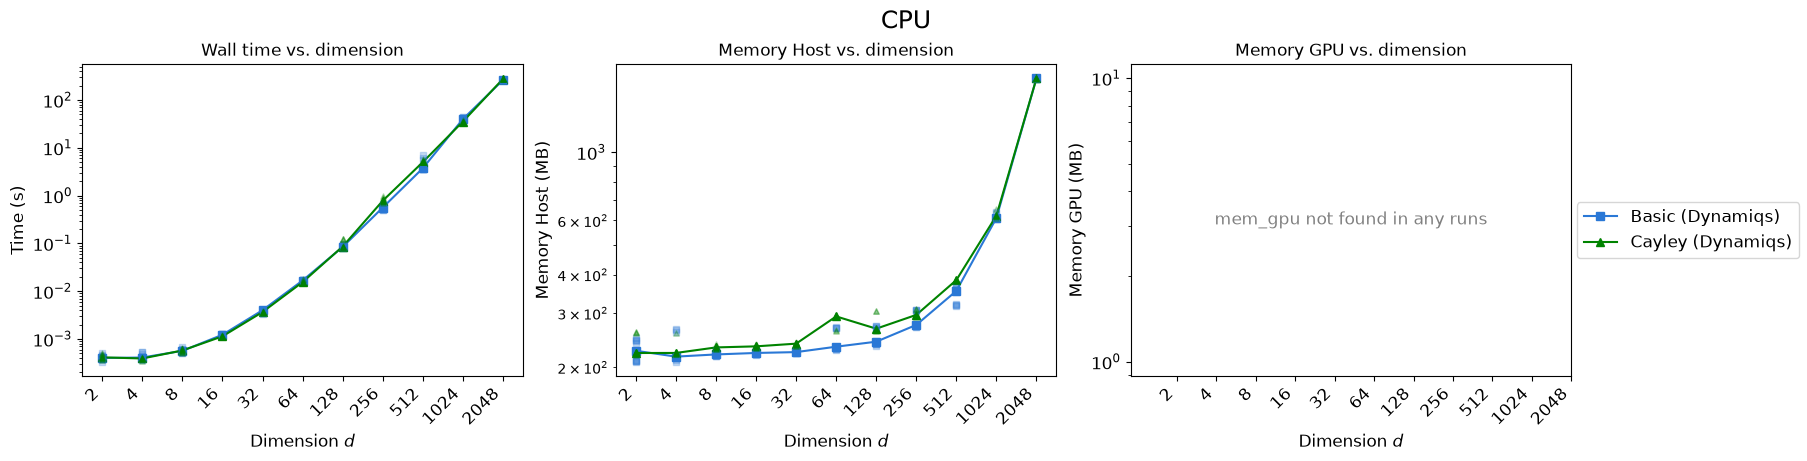

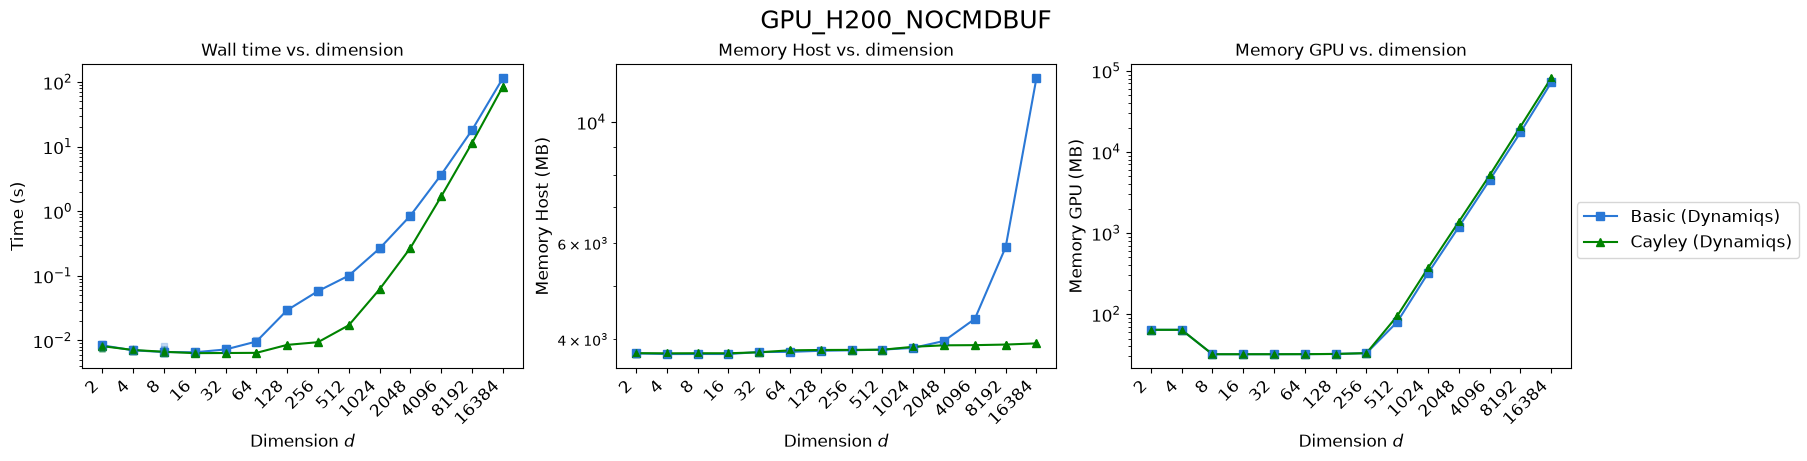

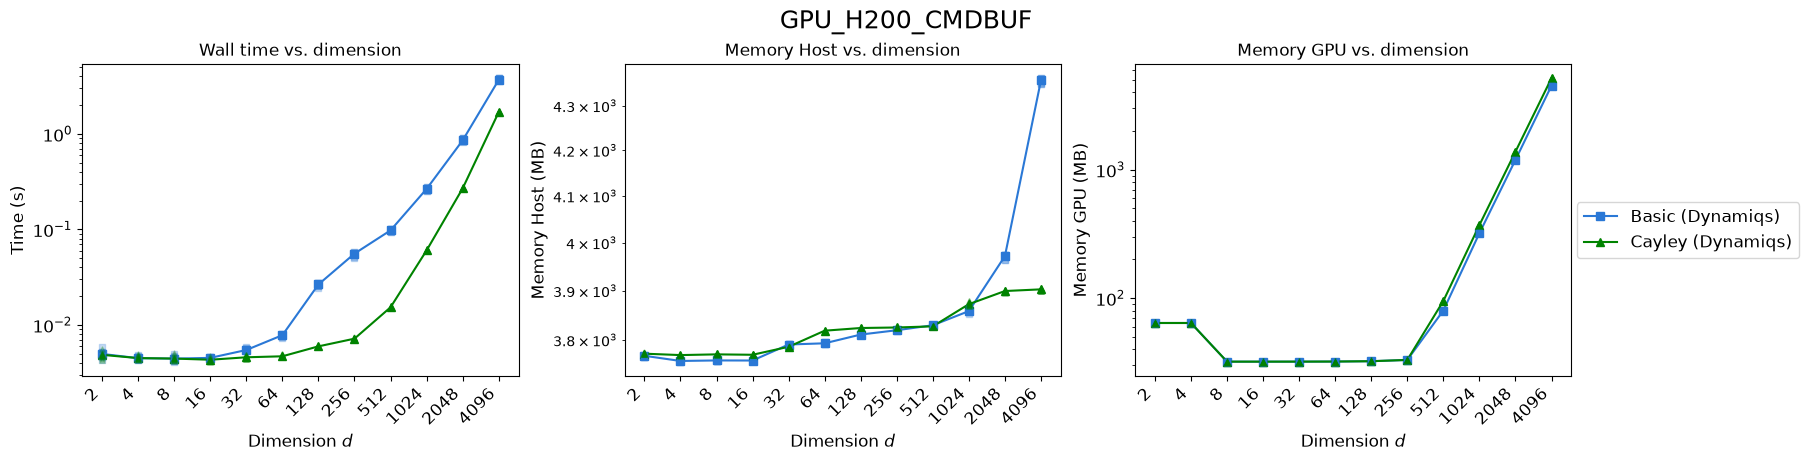

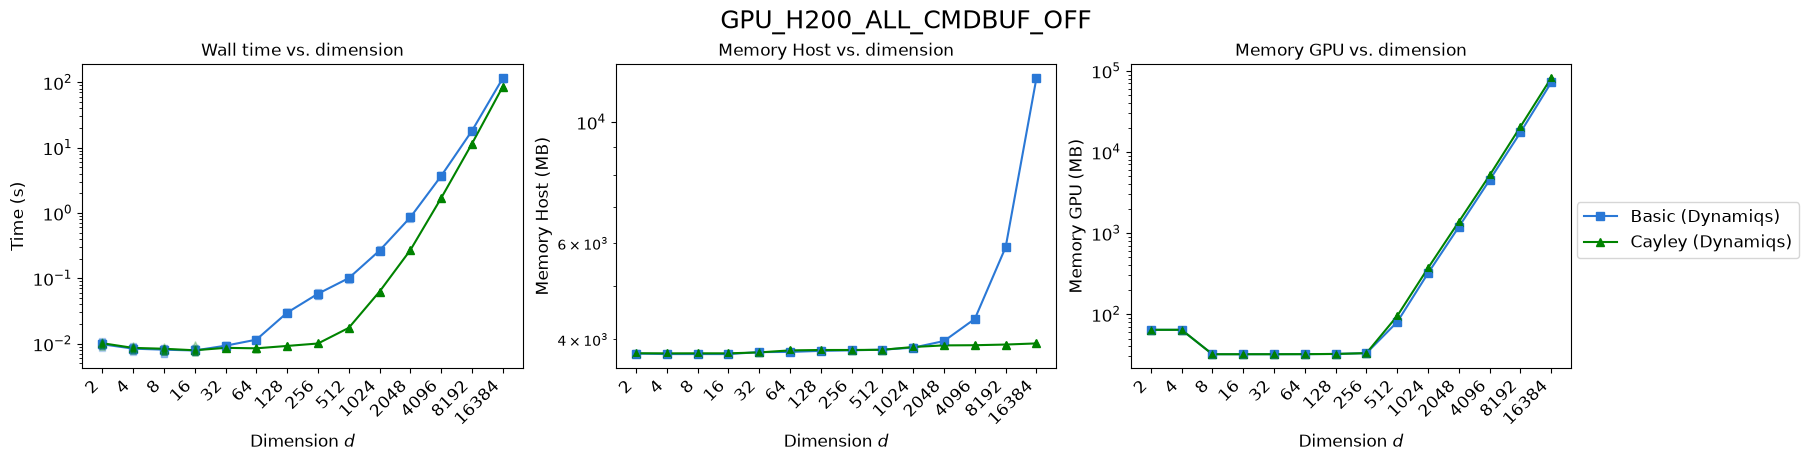

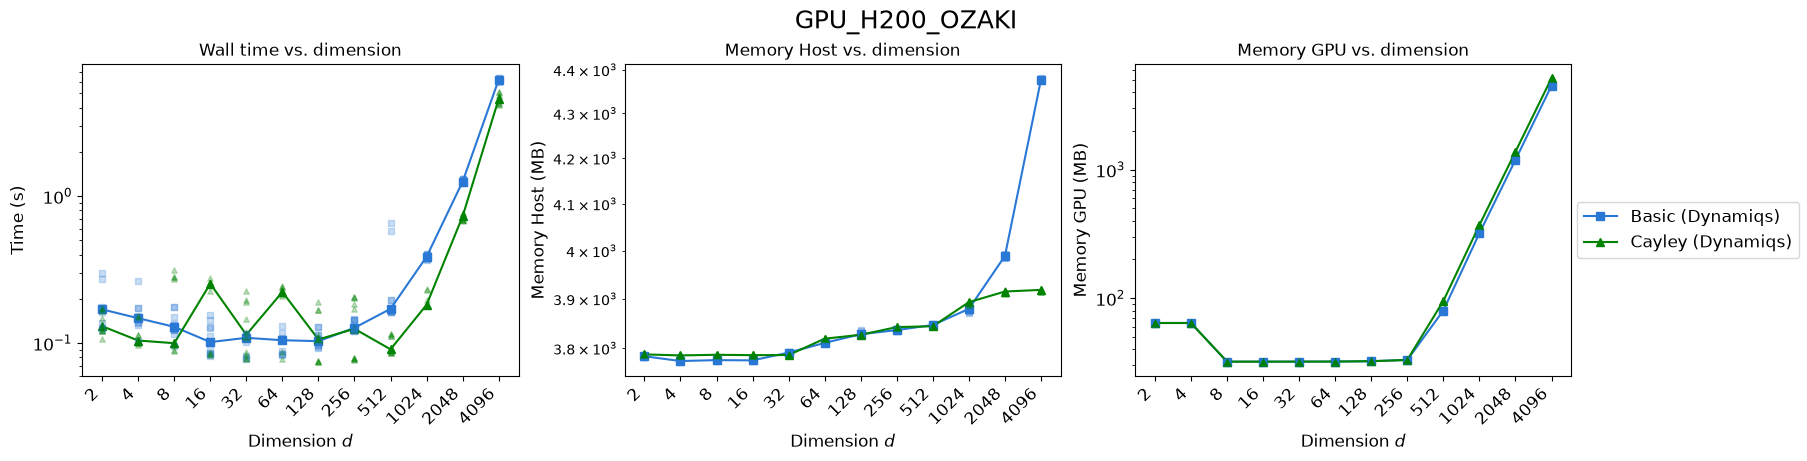

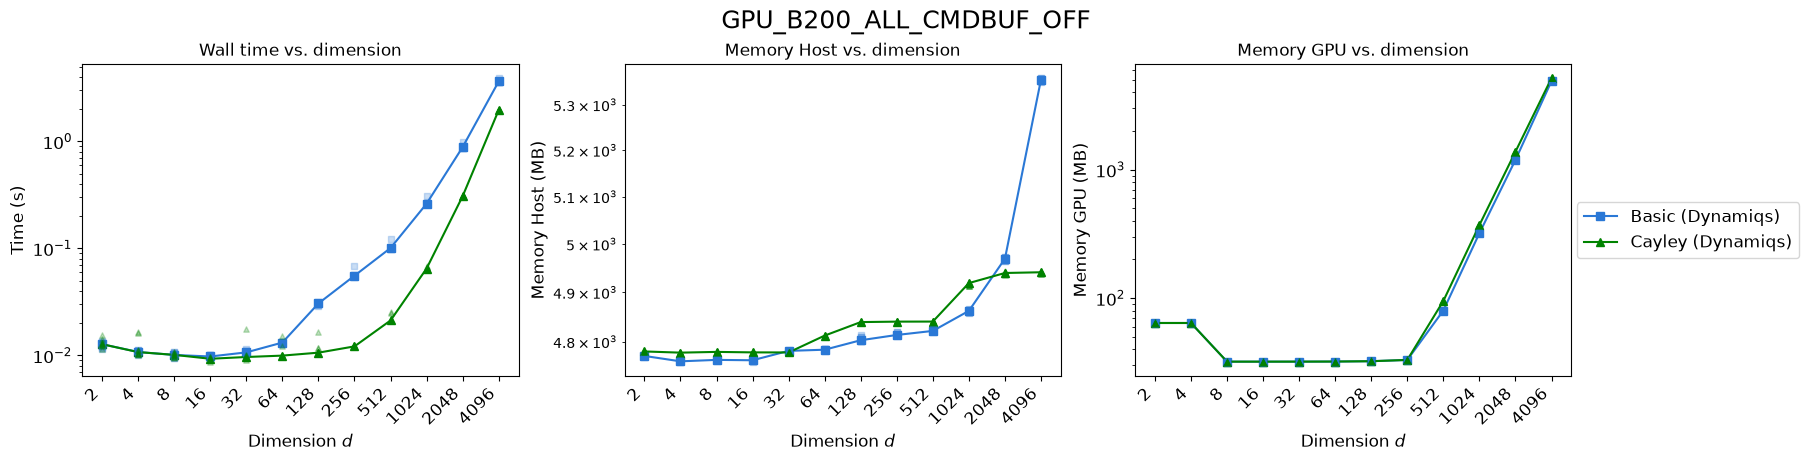

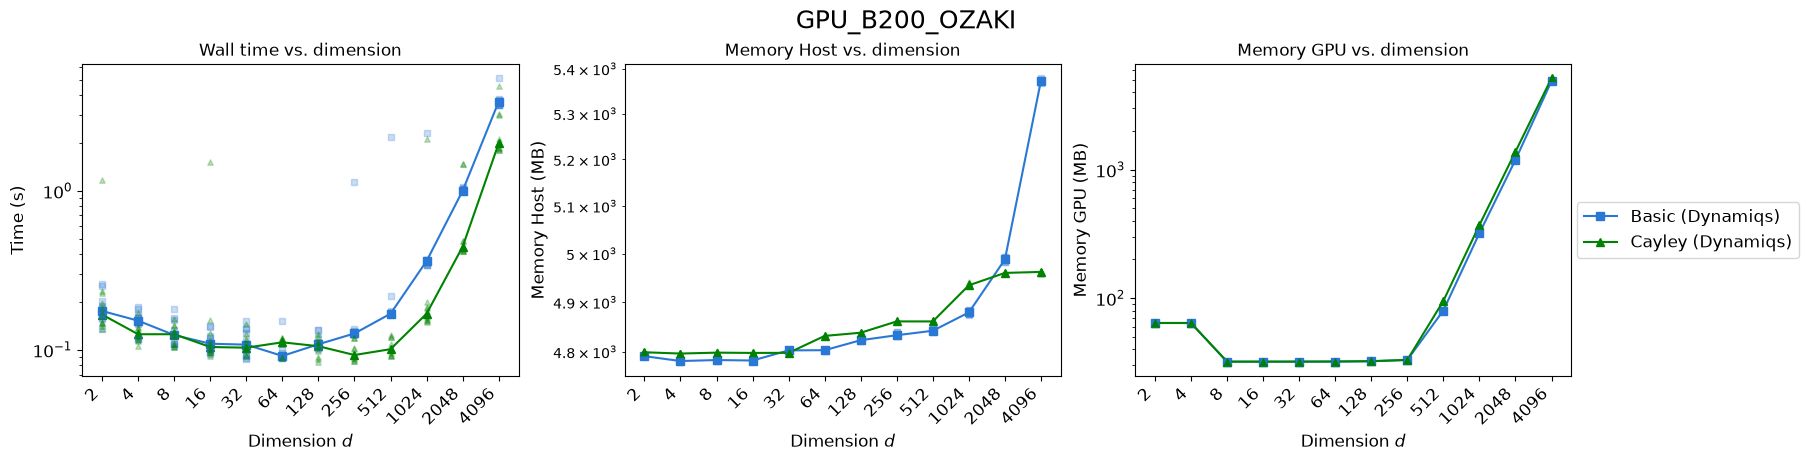

In [5]:
for device in devices:
    plot_compare_runs(data[device], suptitle=f'{device.upper()}')

## Bottleneck breakdown by HLO op category

In [6]:
def plot_breakdown(data_for_device, suptitle="", fontsize=12, normalize=False, 
                   top_n=7, without_command_buffer=False):

    # OP_COLORS = ['#2a78d6', '#008300', '#e87ba4', '#eda100',
    #             '#1baf7a', '#eb6834', '#4a3aa7']
    OP_COLORS = [
        v for k, v in mcolors.TABLEAU_COLORS.items() if k != 'tab:gray'
    ]
    OTHER_COLOR = '#9c9b93'

    fig, axs = plt.subplots(1, len(SOLVERS), 
                            figsize=(6 * len(SOLVERS), 4.5), sharey=False, 
                            constrained_layout=True)
    if len(SOLVERS) == 1:
        axs = [axs]

    for ax, solver in zip(axs, SOLVERS):
        dims, table = collect_breakdown(data_for_device[solver], top_n=top_n)
        x = np.arange(len(dims))
        
        # stacked bar chart (make sure 'other' is last)
        bottom = np.zeros(len(dims))
        ops = [op for op in table 
                if op != 'other' and (
                    not op.startswith('command_buffer') or not without_command_buffer
                )]
        ops += ['other']
        # cycle colors so the list always matches len(ops), even if top_n exceeds len(OP_COLORS)
        colors = [OP_COLORS[i % len(OP_COLORS)] for i in range(len(ops) - 1)] + [OTHER_COLOR]

        # total only over the ops actually being plotted, so normalized shares add up to 100%
        totals = sum(table[op] for op in ops)

        for op, c in zip(ops, colors):
            if normalize:
                share = np.divide(table[op], totals, out=np.zeros_like(totals), where=totals > 0) * 100
            else:
                share = table[op]

            ax.bar(x, share, bottom=bottom, width=0.7, color=c, label=op, 
                   edgecolor='white', linewidth=0.5)
            bottom += share

        ax.set_xlabel('Dimension $d$', fontsize=fontsize)
        ax.set_xticks(x)
        ax.set_xticklabels(dims, rotation=45, ha='right')
        ax.tick_params(axis='both', labelsize=fontsize)
        ax.set_title(solver, fontsize=fontsize)
        ax.legend(fontsize=fontsize, loc='upper left')
        ax.grid(True, axis='y', alpha=0.4)

    if normalize:
        axs[0].set_ylabel('Device time (%)', fontsize=fontsize)
    else:
        axs[0].set_ylabel('Device time (ms)', fontsize=fontsize)

    if suptitle:
        fig.suptitle(suptitle, fontsize=1.5*fontsize)

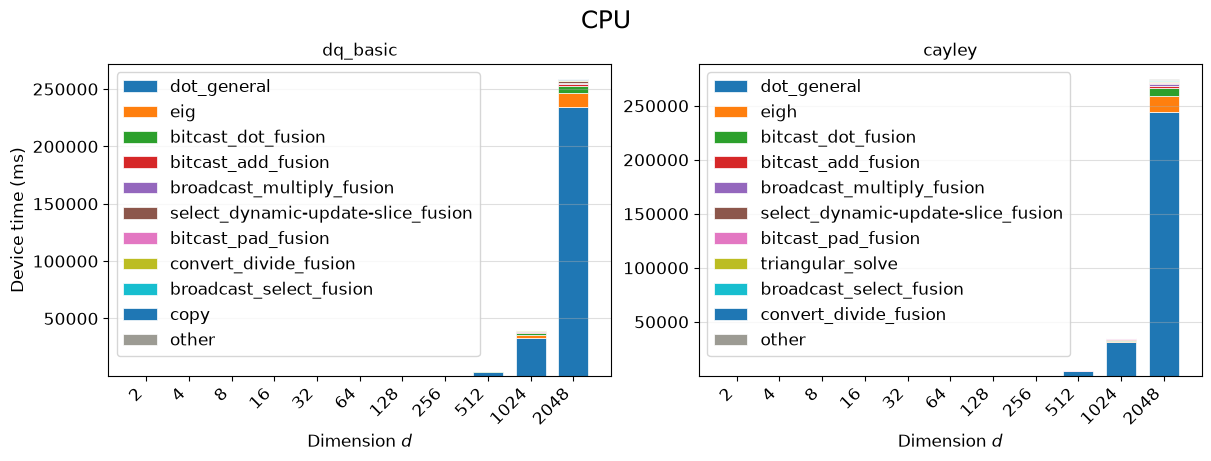

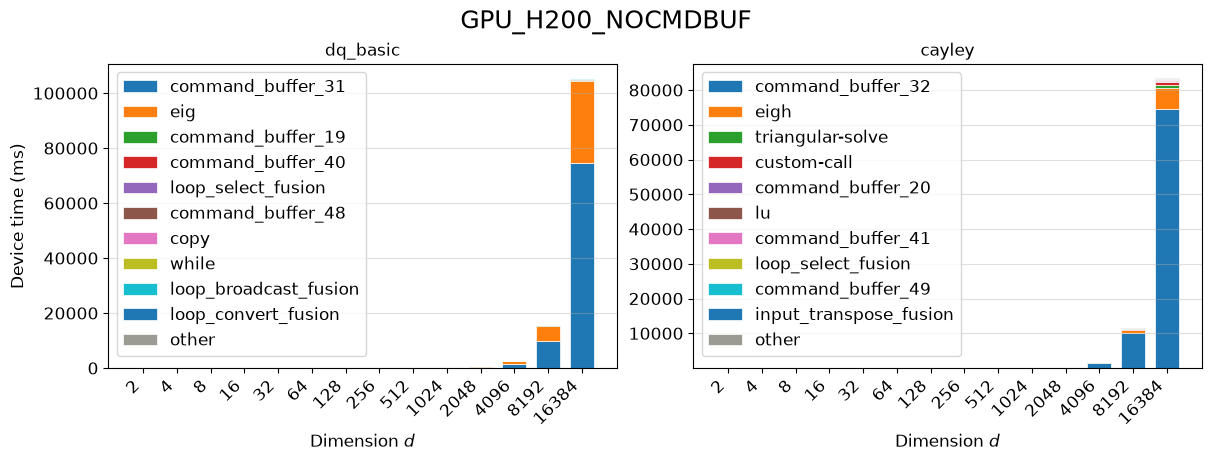

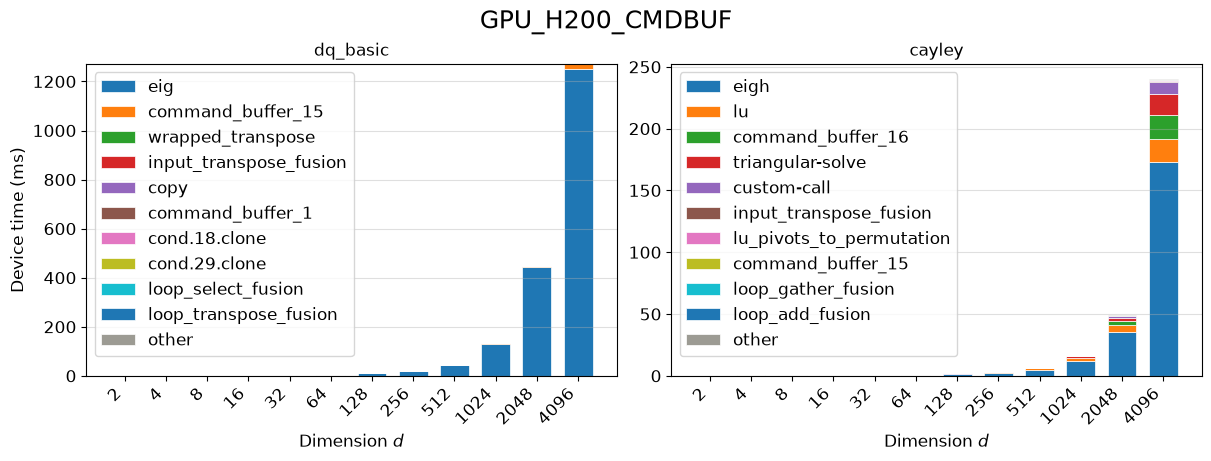

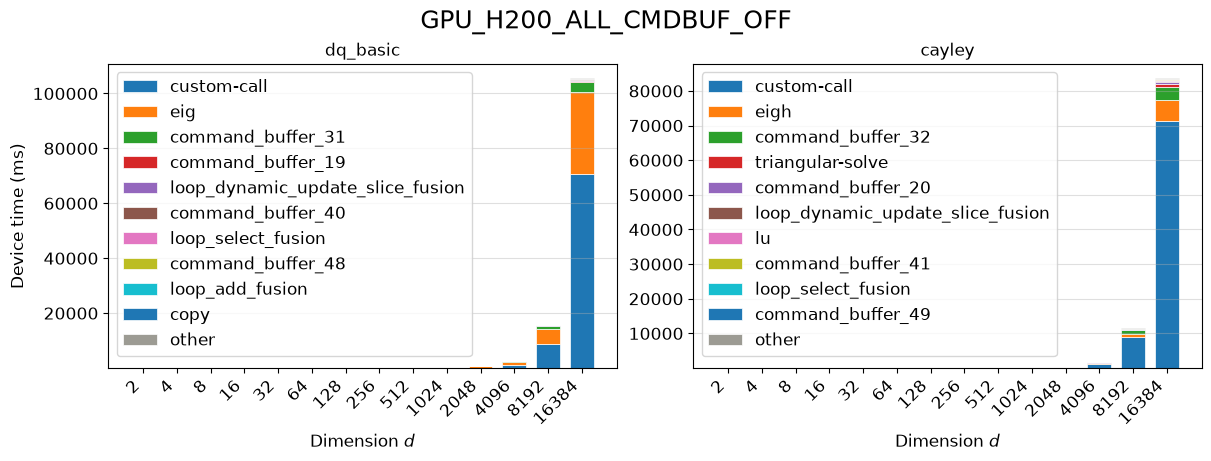

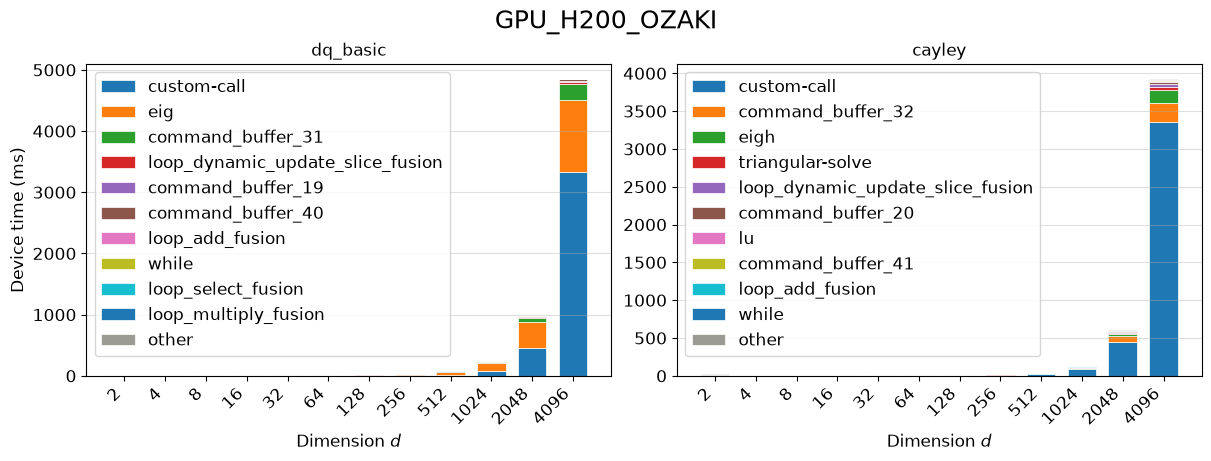

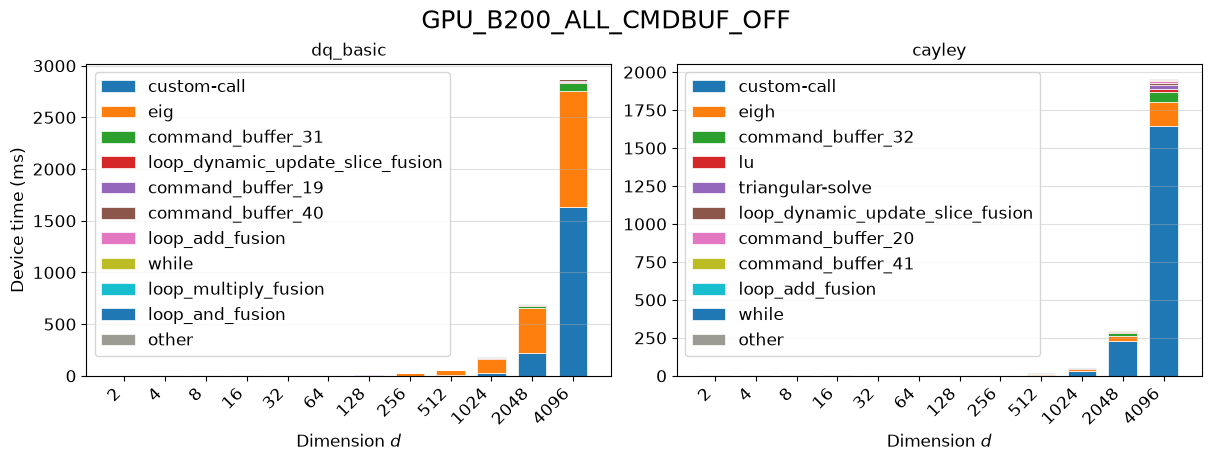

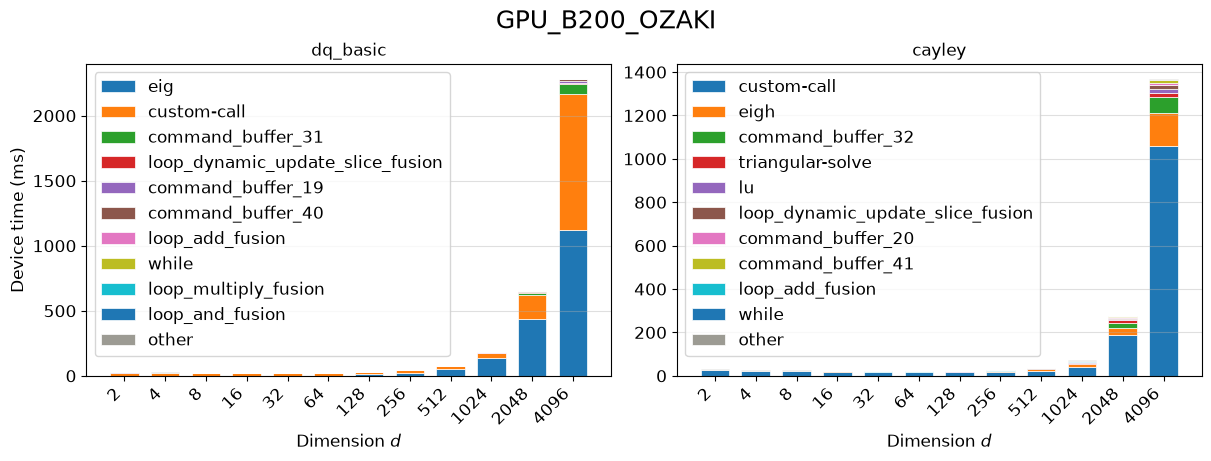

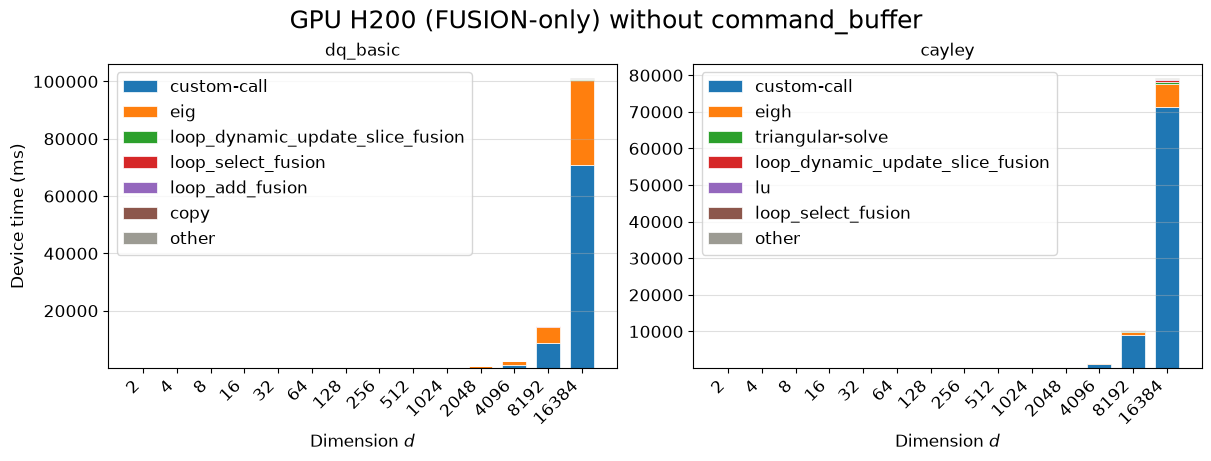

In [7]:
for device in devices:
    plot_breakdown(data[device], suptitle=f'{device.upper()}', top_n=10)

plot_breakdown(data['gpu_h200_all_cmdbuf_off'], suptitle=f'GPU H200 (FUSION-only) without command_buffer', top_n=10, 
                without_command_buffer=True)

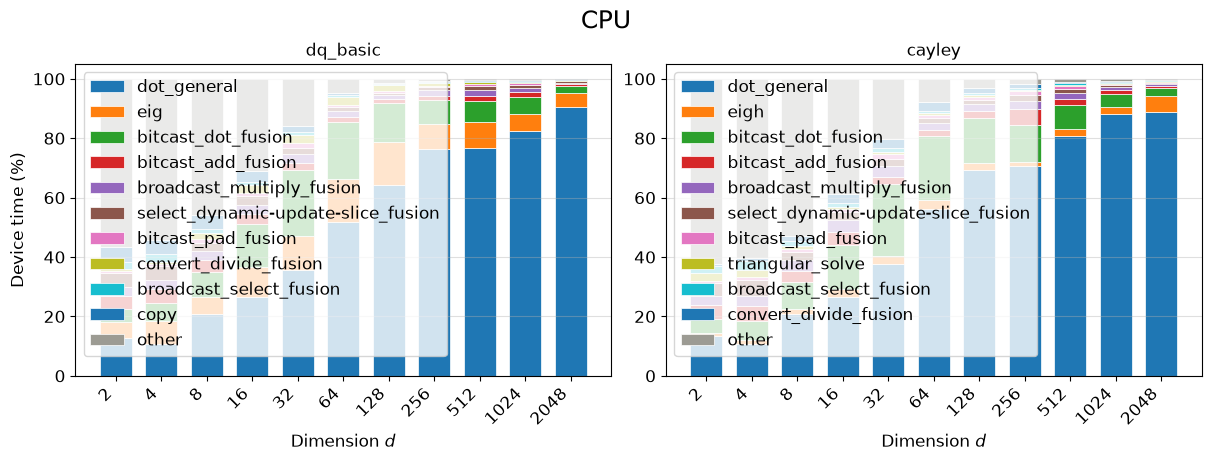

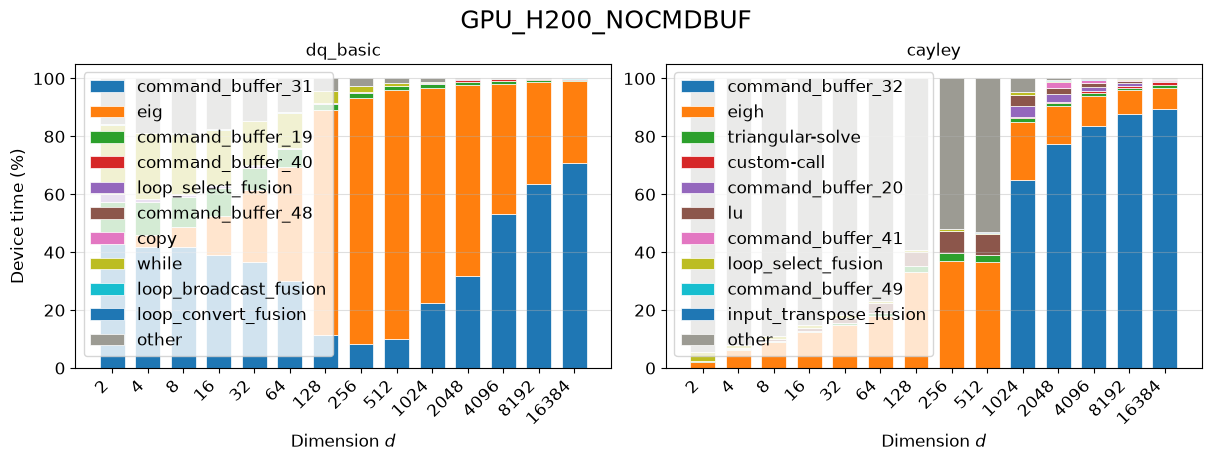

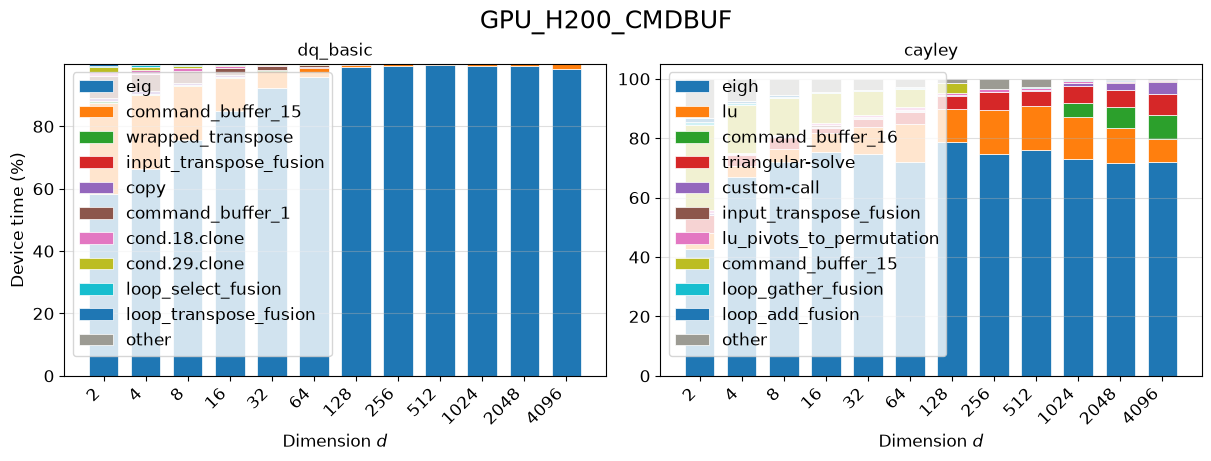

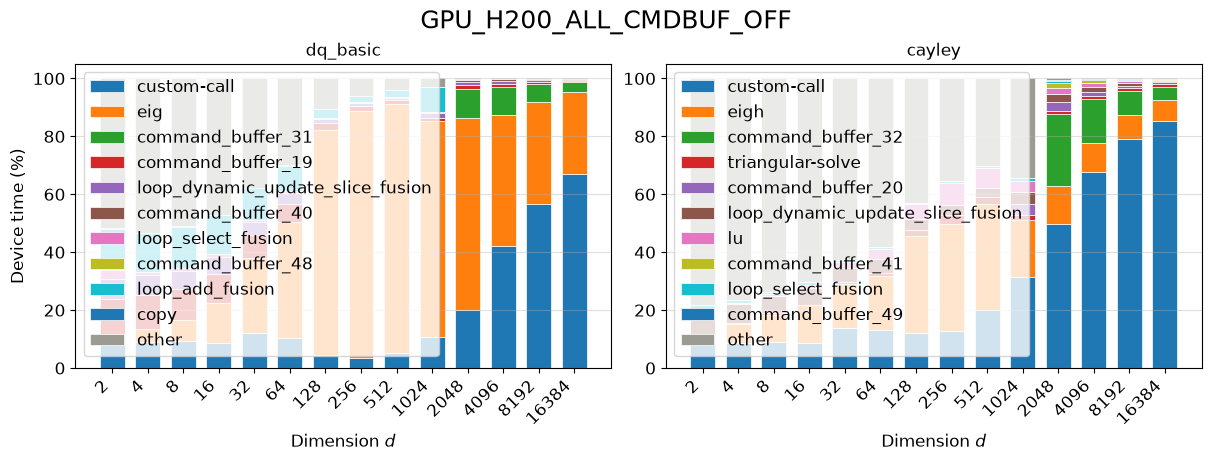

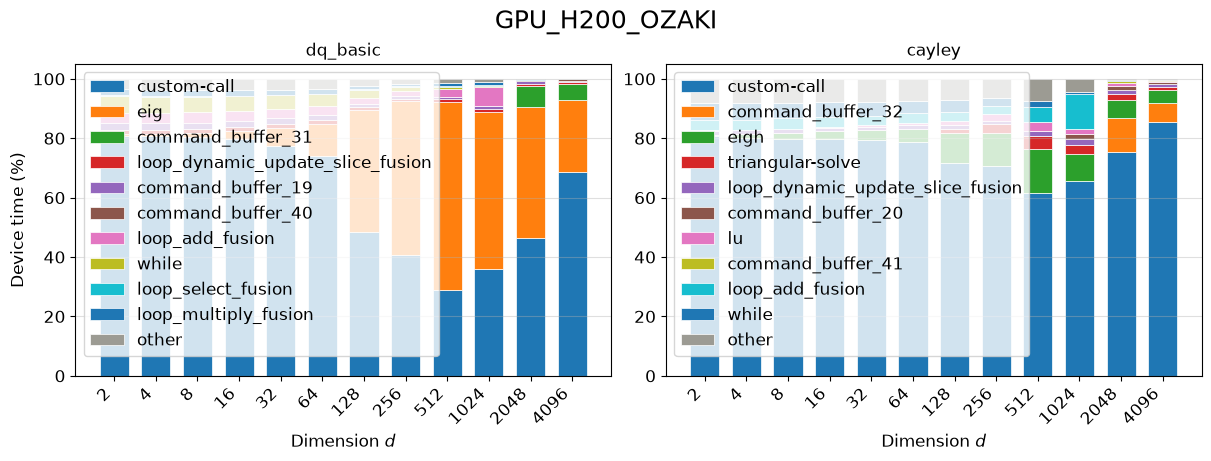

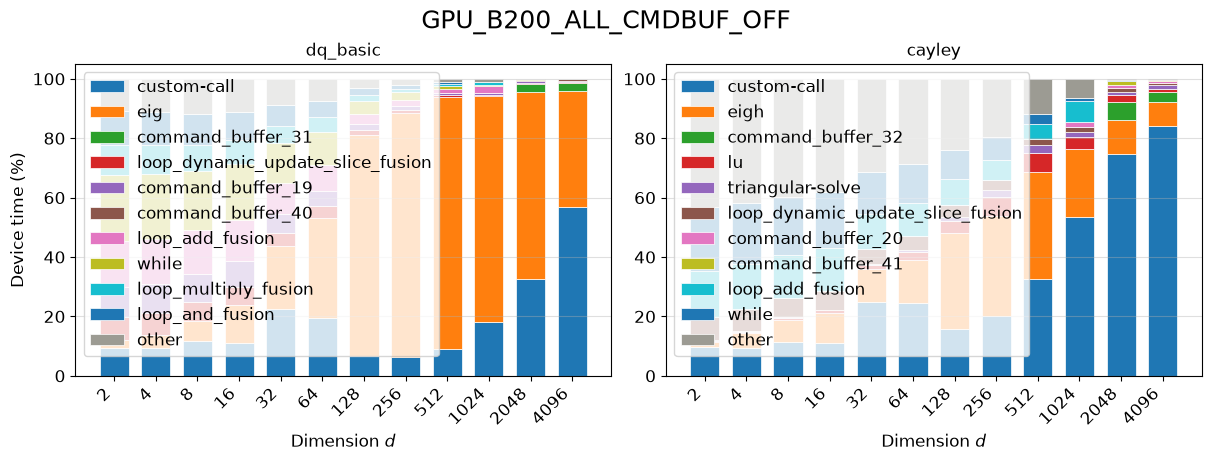

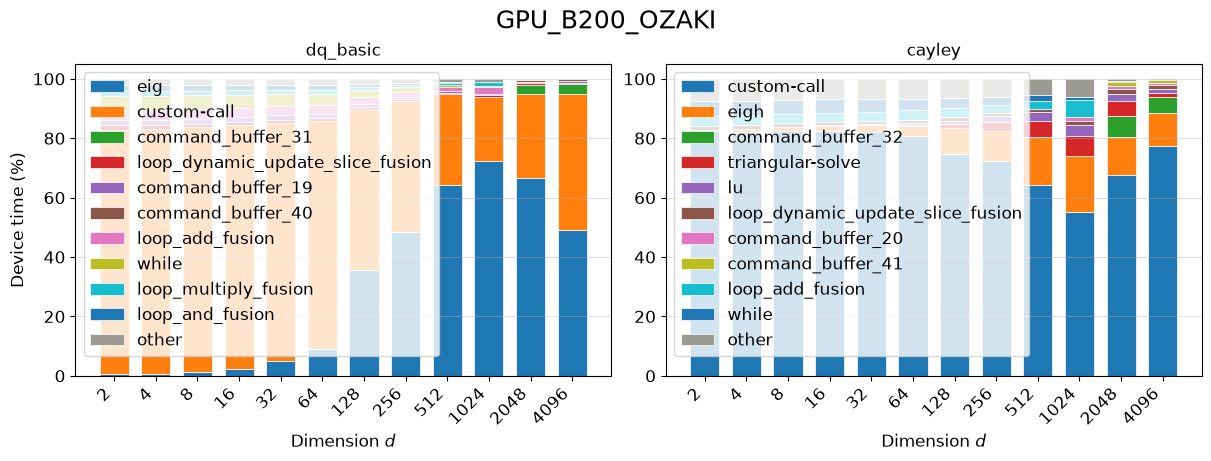

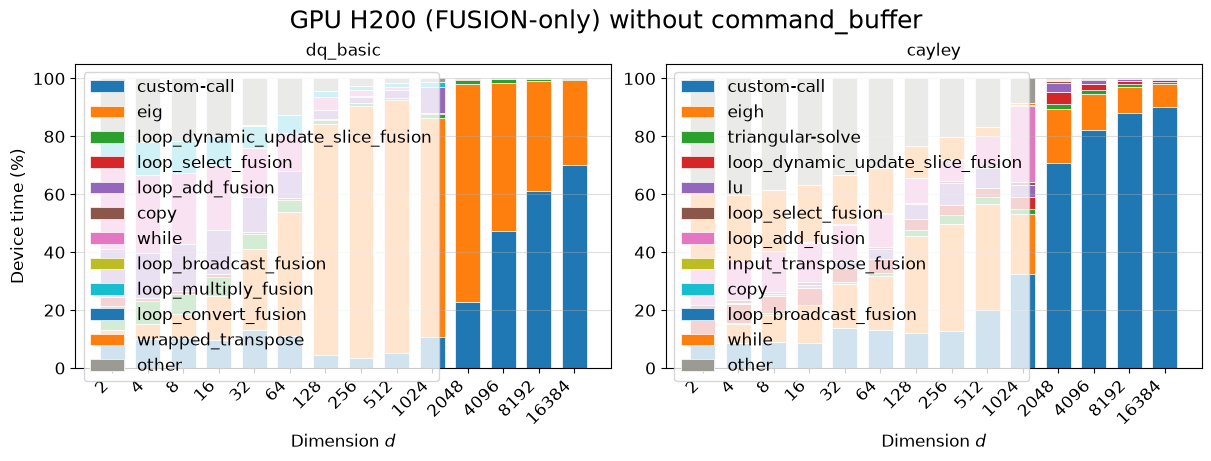

In [8]:
for device in devices:
    plot_breakdown(data[device], suptitle=f'{device.upper()}', normalize=True, top_n=10)

plot_breakdown(data['gpu_h200_all_cmdbuf_off'], suptitle=f'GPU H200 (FUSION-only) without command_buffer', top_n=15, 
                without_command_buffer=True, normalize=True)

---
# Key results

Helpers first: every number below is a median over the 10 runs at each dimension.

In [9]:
def med(ds, solver, d, key='t_total'):
    rows = data[ds][solver].get(d)
    return np.nan if not rows else np.median([r[key] for r in rows])

def dims_of(ds, solver='cayley'):
    return sorted(data[ds][solver])

def op_table(ds, solver, d):
    """{op_name: median ms} for one (dataset, solver, dim)."""
    agg = {}
    for r in data[ds][solver][d]:
        for op, ns in r['op_self_ns'].items():
            agg.setdefault(op, []).append(ns / 1e6)
    return {op: float(np.median(v)) for op, v in agg.items()}

# Coarse buckets. GEMMs reach the trace as cuBLAS `custom-call`s once cuBLAS is
# not graph-captured; Tsit5 stage arithmetic stays wrapped in `command_buffer_*`.
def decompose(ds, solver, d):
    ops = op_table(ds, solver, d)
    b = {'Tsit5: matmuls': 0.0, 'Tsit5: vector arithmetic': 0.0,
         'Diagonalisation': 0.0, 'Other device': 0.0}
    for op, ms in ops.items():
        base = op.split('.')[0]
        if base.startswith('custom-call') or 'gemm' in base:
            b['Tsit5: matmuls'] += ms
        elif base.startswith('command_buffer'):
            b['Tsit5: vector arithmetic'] += ms
        elif base.startswith(('eig', 'lu', 'triangular-solve')):
            b['Diagonalisation'] += ms
        else:
            b['Other device'] += ms
    busy = med(ds, solver, d, 'device_busy_ns') / 1e6
    b['Host + device idle'] = max(med(ds, solver, d) * 1e3 - busy, 0.0)
    return b

In [10]:
# Kernel-level numbers come from the stored `kernels` summary on each row
# (see profiling.kernel_summary), not from re-reading .xplane.pb files.

def kern_vals(ds, solver, d, path):
    """Every run's value of a dotted field, e.g. 'diag.busy_ms'."""
    out = []
    for r in data[ds][solver].get(d, []):
        node = r.get('kernels') or {}
        for part in path.split('.'):
            node = node.get(part) if isinstance(node, dict) else None
            if node is None:
                break
        if isinstance(node, (int, float)):
            out.append(node)
    return out

def kern(ds, solver, d, path, default=np.nan):
    """Median across runs of a dotted field of the kernel summary."""
    v = kern_vals(ds, solver, d, path)
    return float(np.median(v)) if v else default

def kern_table(ds, solver, d, which='gemm_by_kernel'):
    """{kernel_name: {n, ms}} from the first run that has one."""
    for r in data[ds][solver].get(d, []):
        t = (r.get('kernels') or {}).get(which)
        if t:
            return t
    return {}

def has_kernels(ds):
    return any(r.get('kernels')
               for s in data[ds] for rows in data[ds][s].values() for r in rows)

print('datasets carrying kernel summaries:', [d for d in devices if has_kernels(d)])

datasets carrying kernel summaries: ['gpu_h200_nocmdbuf', 'gpu_h200_cmdbuf', 'gpu_h200_all_cmdbuf_off', 'gpu_h200_ozaki', 'gpu_b200_all_cmdbuf_off', 'gpu_b200_ozaki']


## 1. Cayley wins on GPU, but not on CPU

The two solvers share an *identical* propagator - same seed, same Tsit5 integration.
They differ only in how the final propagator is diagonalised: `dq_basic` takes a
general (non-Hermitian) `eig`, Cayley maps the problem to a Hermitian `eigh`.

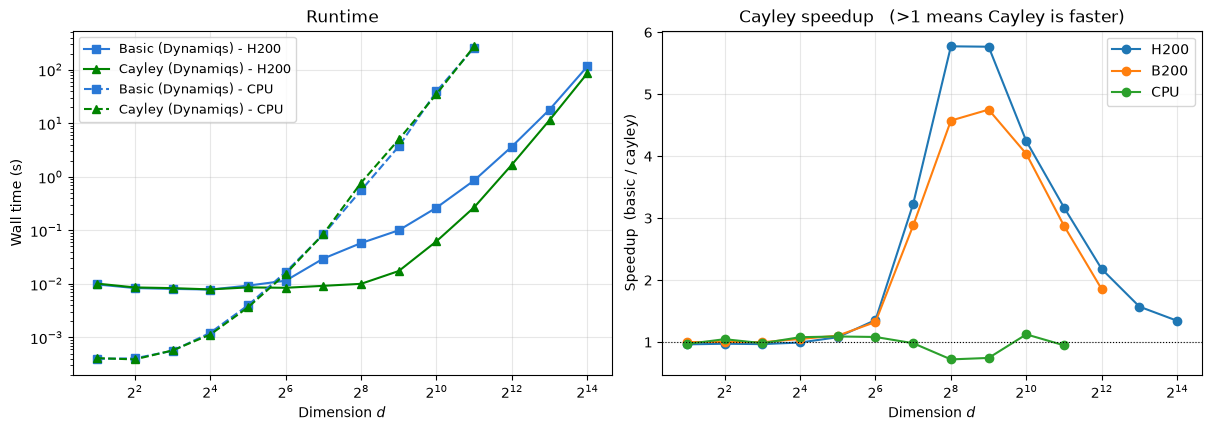

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

for ds, ls, tag in [('gpu_h200_all_cmdbuf_off', '-', 'H200'), ('cpu', '--', 'CPU')]:
    for s, (m, c, lab) in solver_style.items():
        dd = dims_of(ds, s)
        axs[0].plot(dd, [med(ds, s, d) for d in dd], marker=m, color=c,
                    linestyle=ls, label=f'{lab} - {tag}')
axs[0].set_xscale('log', base=2); axs[0].set_yscale('log')
axs[0].set_xlabel('Dimension $d$'); axs[0].set_ylabel('Wall time (s)')
axs[0].set_title('Runtime'); axs[0].legend(fontsize=9); axs[0].grid(alpha=0.3)

for ds, tag in [('gpu_h200_all_cmdbuf_off', 'H200'), ('gpu_b200_all_cmdbuf_off', 'B200'),
                ('cpu', 'CPU')]:
    dd = [d for d in dims_of(ds) if d in data[ds]['dq_basic']]
    axs[1].plot(dd, [med(ds, 'dq_basic', d) / med(ds, 'cayley', d) for d in dd],
                marker='o', label=tag)
axs[1].axhline(1.0, color='k', lw=0.8, ls=':')
axs[1].set_xscale('log', base=2)
axs[1].set_xlabel('Dimension $d$'); axs[1].set_ylabel('Speedup  (basic / cayley)')
axs[1].set_title('Cayley speedup   (>1 means Cayley is faster)')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.show()

**Cayley is 2-6x faster on GPU, and no faster at all on CPU.** The reason is
below: `eig` is what Cayley avoids, and `eig` is only expensive on the GPU.

Both of the next plot's propagator categories are Tsit5 work - they are the two
*kinds* of work it does, not two different stages:

- **Tsit5: matmuls** - the products $H(t)\,U$, one per Runge-Kutta stage.
  110 kernels, 1151 ms at $d=4096$. This is the $O(d^3)$ arithmetic.
- **Tsit5: vector arithmetic** - the elementwise work between those products:
  combining the stages, the error estimate, and the norm reduction for
  step-size control. 885 kernels, 301 ms. $O(d^2)$ and bandwidth-bound.


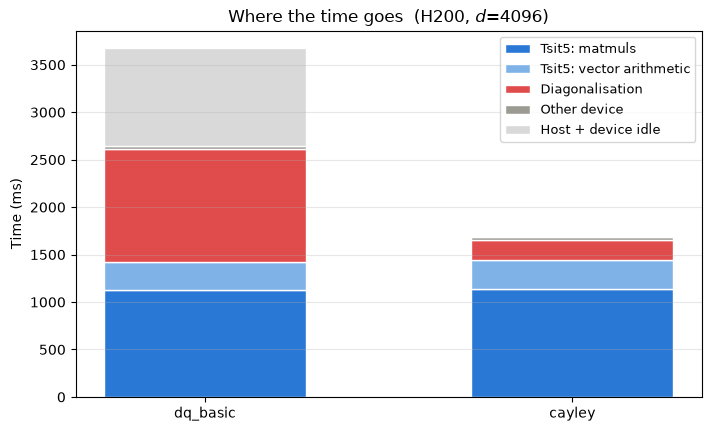

dq_basic  Tsit5: matmuls= 1125.5ms  Tsit5: vector arithmetic=  301.5ms  Diagonalisation= 1182.9ms  Other device=   35.5ms  Host + device idle= 1030.1ms
cayley    Tsit5: matmuls= 1140.2ms  Tsit5: vector arithmetic=  300.9ms  Diagonalisation=  209.8ms  Other device=   36.8ms  Host + device idle=    1.7ms


In [12]:
d = 4096
ds = 'gpu_h200_all_cmdbuf_off'
keys = ['Tsit5: matmuls', 'Tsit5: vector arithmetic', 'Diagonalisation', 'Other device', 'Host + device idle']
colors = ['#2a78d6', '#7fb3e8', '#e04b4b', '#9c9b93', '#d9d9d9']

fig, ax = plt.subplots(figsize=(7, 4.2), constrained_layout=True)
x = np.arange(len(SOLVERS))
bottom = np.zeros(len(SOLVERS))
for k, c in zip(keys, colors):
    vals = np.array([decompose(ds, s, d)[k] for s in SOLVERS])
    ax.bar(x, vals, 0.55, bottom=bottom, label=k, color=c, edgecolor='white')
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(SOLVERS)
ax.set_ylabel('Time (ms)'); ax.set_title(f'Where the time goes  (H200, $d$={d})')
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
plt.show()

for s in SOLVERS:
    b = decompose(ds, s, d)
    print(f'{s:9s} ' + '  '.join(f'{k}={v:7.1f}ms' for k, v in b.items()))

### The number of matrix multiplies does not depend on $d$

Tsit5 picks its step size from the *dynamics*, not the matrix size. Because
`random_hermitian` normalises $H_0$ and $H_1$ to unit spectral norm,
$\|H(t)\|\le 1+A$ at every $d$ - so the integrator takes the same number of
steps regardless of dimension, and the propagator cost is simply

$$\text{propagator} \;\approx\; (\text{fixed number of matmuls}) \times 8d^3 .$$

This holds for any *fixed* $A$: changing $A$ or $\omega_d$ changes the step
count, but not its independence from $d$.

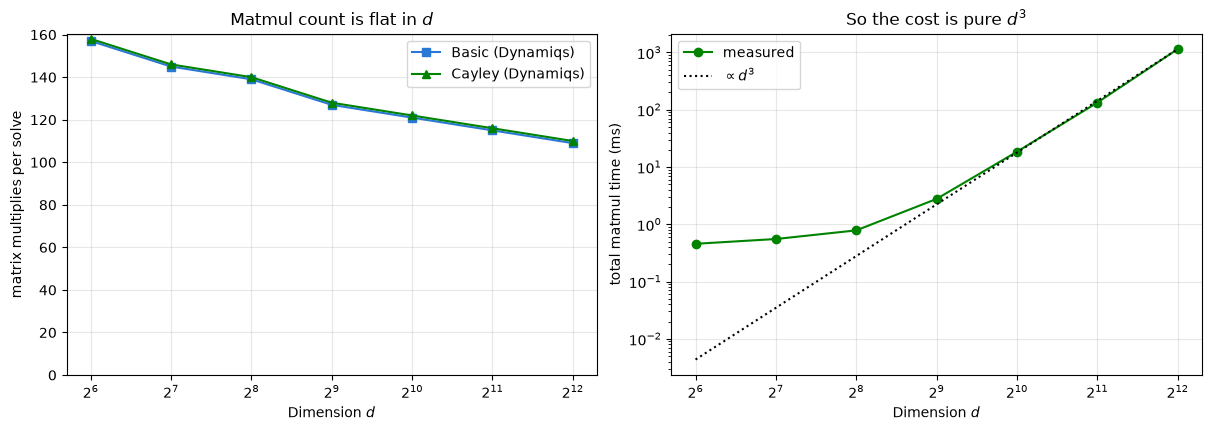

  d=   64:  158 matmuls,      0.5 ms total,      2.9 us each
  d=  128:  146 matmuls,      0.6 ms total,      3.8 us each
  d=  256:  140 matmuls,      0.8 ms total,      5.6 us each
  d=  512:  128 matmuls,      2.8 ms total,     21.6 us each
  d= 1024:  122 matmuls,     18.4 ms total,    151.1 us each
  d= 2048:  116 matmuls,    132.8 ms total,   1145.0 us each
  d= 4096:  110 matmuls,   1140.1 ms total,  10364.7 us each


In [13]:
DIMS_M = [64, 128, 256, 512, 1024, 2048, 4096]
ds = 'gpu_h200_all_cmdbuf_off'
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

for s, (m, c, lab) in solver_style.items():
    axs[0].plot(DIMS_M, [kern(ds, s, d, 'gemm.n') for d in DIMS_M],
                marker=m, color=c, label=lab)
axs[0].set_ylim(0, None)
axs[0].set_xscale('log', base=2); axs[0].set_xlabel('Dimension $d$')
axs[0].set_ylabel('matrix multiplies per solve')
axs[0].set_title('Matmul count is flat in $d$'); axs[0].legend(); axs[0].grid(alpha=0.3)

ms = [kern(ds, 'cayley', d, 'gemm.ms') for d in DIMS_M]
axs[1].plot(DIMS_M, ms, 'o-', color='#008300', label='measured')
ref = np.array(DIMS_M, float) ** 3
axs[1].plot(DIMS_M, ref * ms[-1] / ref[-1], 'k:', label='$\\propto d^3$')
axs[1].set_xscale('log', base=2); axs[1].set_yscale('log')
axs[1].set_xlabel('Dimension $d$'); axs[1].set_ylabel('total matmul time (ms)')
axs[1].set_title('So the cost is pure $d^3$'); axs[1].legend(); axs[1].grid(alpha=0.3)
plt.show()

for d in DIMS_M:
    n_, t_ = kern(ds, 'cayley', d, 'gemm.n'), kern(ds, 'cayley', d, 'gemm.ms')
    print(f'  d={d:5d}: {n_:4.0f} matmuls, {t_:8.1f} ms total, {t_/n_*1000:8.1f} us each')

### Why the two curves have the shapes they do

Cayley stays flat until $d\approx512$ and then climbs steeply; Basic starts
climbing much earlier but more gently. Both run the *same* propagator, so the
whole difference is the diagonalisation - and the two routines behave completely
differently.

`eigh` (Cayley, Hermitian) is a handful of big efficient kernels. `eig` (Basic,
general) is the classic Hessenberg + QR algorithm: a very large number of tiny,
mostly sequential steps. The work is all on the GPU either way - but `eig` is
limited by how fast the CPU can hand off jobs, not by arithmetic.

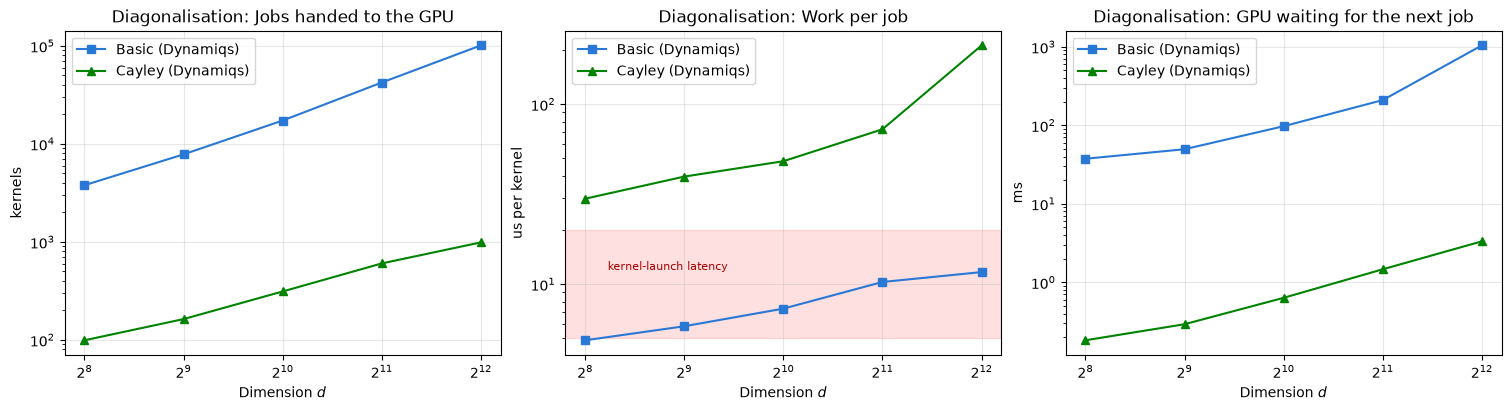

In [14]:
DD = [256, 512, 1024, 2048, 4096]
ds = 'gpu_h200_all_cmdbuf_off'

fig, axs = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for s, (m, c, lab) in solver_style.items():
    axs[0].plot(DD, [kern(ds, s, d, 'diag.n') for d in DD], marker=m, color=c, label=lab)
    axs[1].plot(DD, [1000 * kern(ds, s, d, 'diag.busy_ms') / kern(ds, s, d, 'diag.n')
                     for d in DD], marker=m, color=c, label=lab)
    axs[2].plot(DD, [kern(ds, s, d, 'diag.idle_ms') for d in DD], marker=m, color=c, label=lab)

axs[1].axhspan(5, 20, color='red', alpha=0.12)
axs[1].text(300, 12, 'kernel-launch latency', fontsize=8, color='#a00')
for ax, t, yl in [(axs[0], 'Jobs handed to the GPU', 'kernels'),
                  (axs[1], 'Work per job', 'us per kernel'),
                  (axs[2], 'GPU waiting for the next job', 'ms')]:
    ax.set_xscale('log', base=2); ax.set_yscale('log')
    ax.set_xlabel('Dimension $d$'); ax.set_ylabel(yl)
    ax.set_title(f'Diagonalisation: {t}'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

Left: `eig` fires ~100x more jobs. Middle: each of those jobs is only ~10 us of
work - inside the red band, i.e. about as expensive to *launch* as to run, so
`eig` is paying for launches rather than arithmetic. `eigh`'s jobs grow past
200 us, so it does real work per launch. Right: the consequence - the GPU idles
for ~950 ms during `eig` and 3 ms during `eigh`.

Neither routine is anywhere near the hardware limit, though - see section 1c.

### 1c. Why the *speedup* shrinks even though Cayley always wins

Two separate things get confused here, so keep them apart:

- **Cayley is faster at every dimension** - the gap above is positive everywhere
  and growing in absolute terms (0.08 s at $d$=512 to 1.99 s at $d$=4096).
- **The speedup *ratio* still falls**, 5.8x to 2.2x.

Both are true, and the reason is that the two solvers share an identical
propagator which Cayley does nothing to improve. Split the runtime into the
shared part and the part that differs:

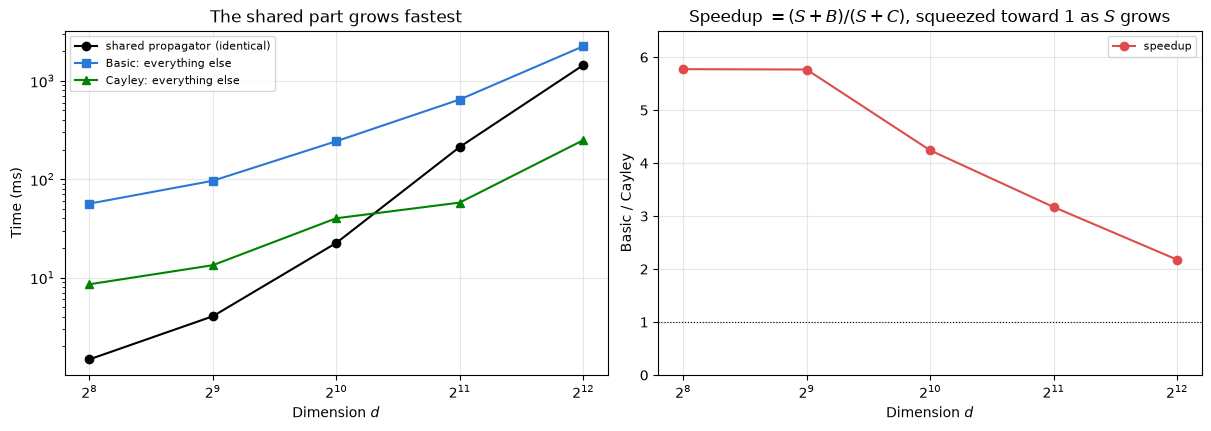

shared propagator scales as d^2.48   Basic-extra d^1.33   Cayley-extra d^1.22


In [15]:
DD = [256, 512, 1024, 2048, 4096]
ds = 'gpu_h200_all_cmdbuf_off'

def op_ms(s, d, pref):
    return float(np.median([sum(v for k, v in r['op_self_ns'].items() if k.startswith(pref)) / 1e6
                            for r in data[ds][s][d]]))

shared = [op_ms('cayley', d, 'custom-call') + op_ms('cayley', d, 'command_buffer') for d in DD]
basic_x = [med(ds, 'dq_basic', d) * 1e3 - s for d, s in zip(DD, shared)]
cay_x = [med(ds, 'cayley', d) * 1e3 - s for d, s in zip(DD, shared)]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
axs[0].plot(DD, shared, 'ko-', label='shared propagator (identical)')
axs[0].plot(DD, basic_x, 's-', color='#2a78d6', label='Basic: everything else')
axs[0].plot(DD, cay_x, '^-', color='#008300', label='Cayley: everything else')
axs[0].set_xscale('log', base=2); axs[0].set_yscale('log')
axs[0].set_xlabel('Dimension $d$'); axs[0].set_ylabel('Time (ms)')
axs[0].set_title('The shared part grows fastest'); axs[0].legend(fontsize=8); axs[0].grid(alpha=0.3)

axs[1].plot(DD, [(s + b) / (s + c) for s, b, c in zip(shared, basic_x, cay_x)],
            'o-', color='#e04b4b', label='speedup')
axs[1].axhline(1, color='k', lw=0.8, ls=':')
axs[1].set_xscale('log', base=2); axs[1].set_ylim(0, 6.5)
axs[1].set_xlabel('Dimension $d$'); axs[1].set_ylabel('Basic / Cayley')
axs[1].set_title('Speedup $=(S+B)/(S+C)$, squeezed toward 1 as $S$ grows')
axs[1].legend(fontsize=8); axs[1].grid(alpha=0.3)
plt.show()

sl = lambda v: np.mean([np.log2(b / a) for a, b in zip(v, v[1:])])
print(f'shared propagator scales as d^{sl(shared):.2f}   '
      f'Basic-extra d^{sl(basic_x):.2f}   Cayley-extra d^{sl(cay_x):.2f}')

The shared propagator grows like $d^{2.5}$ (heading to $d^3$), while *both*
diagonalisation costs grow like $d^{1.3}$. So the part Cayley cannot improve is
taking over, and the ratio is squeezed toward 1. This is Amdahl's law: you can
only speed up the part you change. Cayley's ceiling is set by the propagator, not
by how good `eigh` is.

### Why neither slope reaches $d^3$

Both routines do $\Theta(d^3)$ arithmetic, so both *must* end up at slope 3.
Neither is there because neither is anywhere near using the hardware:

eig  (Basic): d=256:0.03%  d=512:0.11%  d=1024:0.32%  d=2048:0.74%  d=4096:2.17%
eigh (Cayley): d=256:0.08%  d=512:0.28%  d=1024:0.96%  d=2048:2.64%  d=4096:4.40%


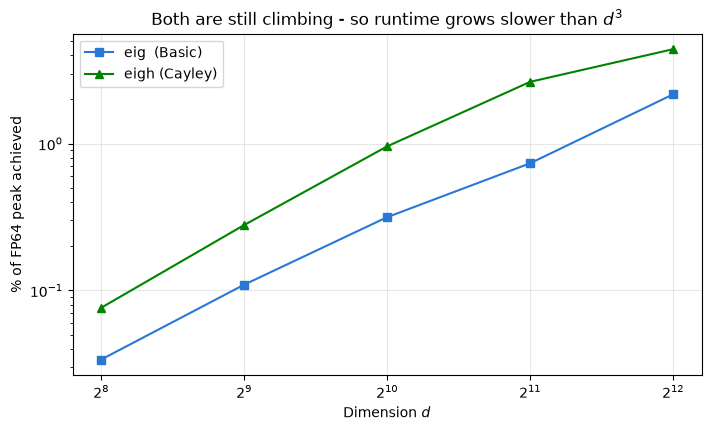

In [16]:
DD = [256, 512, 1024, 2048, 4096]
ds = 'gpu_h200_all_cmdbuf_off'
PEAK = 67e3   # H200 FP64 tensor-core peak, GFLOP/s

fig, ax = plt.subplots(figsize=(7, 4.2), constrained_layout=True)
for s, flops, name, (m, c, _) in [('dq_basic', 25, 'eig  (Basic)', solver_style['dq_basic']),
                                  ('cayley', 9, 'eigh (Cayley)', solver_style['cayley'])]:
    eff = [100 * (flops * d ** 3 / (kern(ds, s, d, 'diag.busy_ms') / 1e3) / 1e9) / PEAK
           for d in DD]
    ax.plot(DD, eff, marker=m, color=c, label=name)
    print(f'{name}: ' + '  '.join(f'd={d}:{e:.2f}%' for d, e in zip(DD, eff)))
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_xlabel('Dimension $d$'); ax.set_ylabel('% of FP64 peak achieved')
ax.set_title('Both are still climbing - so runtime grows slower than $d^3$')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

`eig` goes from 0.03% to 2.2% of peak across this range; `eigh` from 0.08% to
4.4%. Runtime $=$ arithmetic $/$ efficiency, so while efficiency is still
climbing the runtime grows *more slowly* than the $d^3$ arithmetic - which is
exactly the sub-cubic slope. Both will reach slope 3 only once efficiency
plateaus, and with 95%+ of the machine still unused, that is a long way off.

So your intuition was right: better parallelism does show up as a shallower
curve, because the GPU is being used better at larger $d$. What it does *not* do
is let `eig` overtake `eigh` - `eigh` is about twice as efficient at every
dimension, and starts from a 6x smaller kernel count.

At $d=4096$ the general `eig` fires **101,408** separate GPU jobs against 989 for
`eigh`, and spends **950 ms doing nothing** in between waiting for the next one.
`eigh` wastes 3 ms. That launch cost is already large at $d=256$, which is why
Basic leaves the flat region long before Cayley does.

**The advantage does not vanish - only the ratio shrinks.** In absolute terms the
gap grows from 0.08 s at $d=512$ to 1.99 s at $d=4096$. The ratio falls (5.8x to
2.2x) because Cayley's own matrix multiplies grow like $d^3$ and eventually
dominate its runtime, while `eig` grows more slowly than $d^3$. Fitting $d=512\ldots4096$ gives Cayley $\sim d^{2.19}$ and Basic $\sim d^{1.73}$.

## 2. The profiler used to *be* the measurement

`t_total` is now timed with no profiler attached; `t_total_traced` is the same
solve with tracing on. The gap is a near-constant offset, so at small $d$ the
old (traced) numbers were measuring profiler start-up and nothing else.

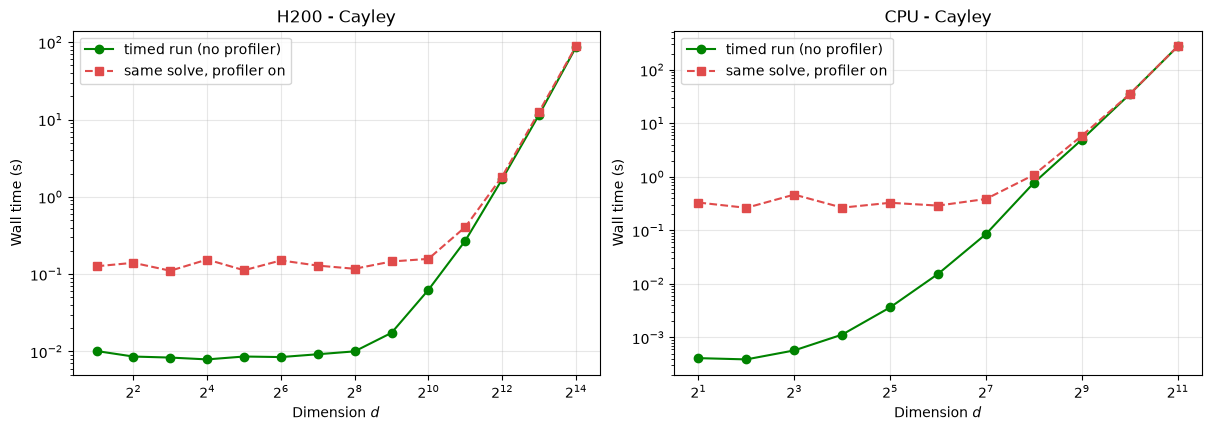

profiler overhead, H200 cayley (s):
  d=    2  timed= 0.01014  traced= 0.12657  ratio=  12.5x
  d=    4  timed= 0.00860  traced= 0.14031  ratio=  16.3x
  d=    8  timed= 0.00835  traced= 0.11077  ratio=  13.3x
  d=   16  timed= 0.00790  traced= 0.15467  ratio=  19.6x
  d=   32  timed= 0.00861  traced= 0.11235  ratio=  13.0x
  d=   64  timed= 0.00847  traced= 0.15059  ratio=  17.8x
  d=  128  timed= 0.00921  traced= 0.12909  ratio=  14.0x
  d=  256  timed= 0.01004  traced= 0.11748  ratio=  11.7x
  d=  512  timed= 0.01743  traced= 0.14587  ratio=   8.4x
  d= 1024  timed= 0.06263  traced= 0.15771  ratio=   2.5x
  d= 2048  timed= 0.27045  traced= 0.40680  ratio=   1.5x
  d= 4096  timed= 1.69003  traced= 1.83092  ratio=   1.1x
  d= 8192  timed=11.50794  traced=12.57718  ratio=   1.1x
  d=16384  timed=85.79897  traced=88.49491  ratio=   1.0x


In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for ax, ds, tag in [(axs[0], 'gpu_h200_all_cmdbuf_off', 'H200'), (axs[1], 'cpu', 'CPU')]:
    dd = dims_of(ds, 'cayley')
    ax.plot(dd, [med(ds, 'cayley', d) for d in dd], 'o-',
            color='#008300', label='timed run (no profiler)')
    ax.plot(dd, [med(ds, 'cayley', d, 't_total_traced') for d in dd], 's--',
            color='#e04b4b', label='same solve, profiler on')
    ax.set_xscale('log', base=2); ax.set_yscale('log')
    ax.set_xlabel('Dimension $d$'); ax.set_ylabel('Wall time (s)')
    ax.set_title(f'{tag} - Cayley'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

print('profiler overhead, H200 cayley (s):')
for d in dims_of('gpu_h200_all_cmdbuf_off', 'cayley'):
    t = med('gpu_h200_all_cmdbuf_off', 'cayley', d)
    tr = med('gpu_h200_all_cmdbuf_off', 'cayley', d, 't_total_traced')
    print(f'  d={d:5d}  timed={t:8.5f}  traced={tr:8.5f}  ratio={tr/t:6.1f}x')

## 3. What the "command buffer" setting does, and whether it helps

The GPU cannot run your program by itself. The CPU has to hand it one small job
at a time - a *kernel* - and each handoff costs a few microseconds of pure
bookkeeping. Cayley at $d=512$ needs about 1700 handoffs.

A **command buffer** (a CUDA graph) records that whole sequence once and then
replays it with a single handoff, so most of the bookkeeping disappears.
`+WHILE,+CONDITIONAL` tells XLA to record the entire ODE loop this way.

Below: how many handoffs each setting needs, and what that is worth.

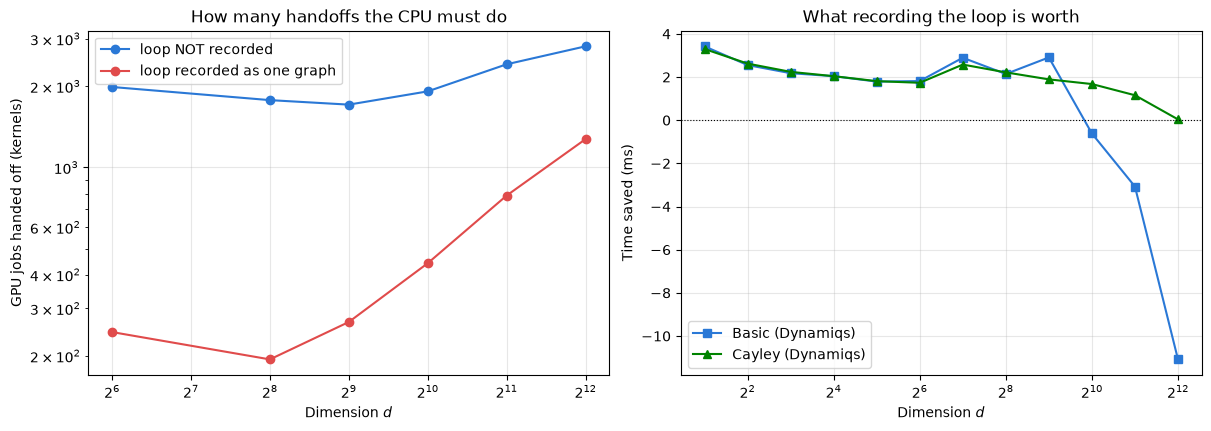

d=  512: solve takes     17.2 ms, recording saves   1.9 ms  (11.0%)
d= 4096: solve takes   1690.4 ms, recording saves   0.0 ms  ( 0.0%)


In [18]:
DIMS_K = [64, 256, 512, 1024, 2048, 4096]
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

for ds, lab, c in [('gpu_h200_nocmdbuf', 'loop NOT recorded', '#2a78d6'),
                   ('gpu_h200_cmdbuf', 'loop recorded as one graph', '#e04b4b')]:
    axs[0].plot(DIMS_K, [kern(ds, 'cayley', d, 'n_kernels') for d in DIMS_K],
                'o-', color=c, label=lab)
axs[0].set_xscale('log', base=2); axs[0].set_yscale('log')
axs[0].set_xlabel('Dimension $d$'); axs[0].set_ylabel('GPU jobs handed off (kernels)')
axs[0].set_title('How many handoffs the CPU must do'); axs[0].legend(); axs[0].grid(alpha=0.3)

for s, (m, c, lab) in solver_style.items():
    dd = dims_of('gpu_h200_cmdbuf', s)
    saved = [(med('gpu_h200_nocmdbuf', s, d) - med('gpu_h200_cmdbuf', s, d)) * 1e3 for d in dd]
    axs[1].plot(dd, saved, marker=m, color=c, label=lab)
axs[1].axhline(0, color='k', lw=0.8, ls=':')
axs[1].set_xscale('log', base=2); axs[1].set_xlabel('Dimension $d$')
axs[1].set_ylabel('Time saved (ms)')
axs[1].set_title('What recording the loop is worth'); axs[1].legend(); axs[1].grid(alpha=0.3)
plt.show()

for d in [512, 4096]:
    tot = med('gpu_h200_nocmdbuf', 'cayley', d) * 1e3
    sav = tot - med('gpu_h200_cmdbuf', 'cayley', d) * 1e3
    print(f'd={d:5d}: solve takes {tot:8.1f} ms, recording saves {sav:5.1f} ms  ({100*sav/tot:4.1f}%)')

**Verdict: it is not a source of efficiency.** Recording the loop removes a
*fixed* ~2 ms of bookkeeping, no matter how big the problem is. At $d=512$ that
is 11% of the solve; at $d=4096$ it is 0.1%. It helps only when the problem is
so small that the solve is mostly bookkeeping anyway.

It also has a cost worth knowing about: once the loop is recorded as one graph,
the profiler can no longer see the individual jobs inside it. Below, both runs
take the same wall time, but with recording on, most of the work becomes
invisible and shows up as "idle".

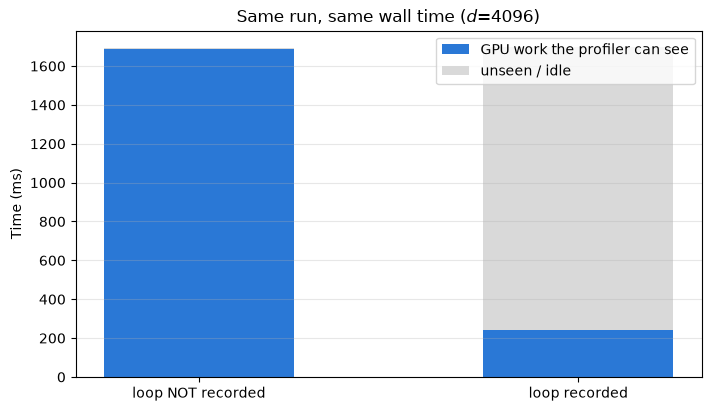

loop NOT recorded      wall= 1690.4 ms   kernels=   2812   work seen= 1687.4 ms
loop recorded          wall= 1690.3 ms   kernels=   1273   work seen=  240.7 ms


In [19]:
d = 4096
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
sets = [('gpu_h200_nocmdbuf', 'loop NOT recorded'), ('gpu_h200_cmdbuf', 'loop recorded')]
x = np.arange(len(sets))
busy = np.array([kern(s, 'cayley', d, 'busy_ms') for s, _ in sets])
idle = np.array([kern(s, 'cayley', d, 'idle_ms') for s, _ in sets])
ax.bar(x, busy, 0.5, label='GPU work the profiler can see', color='#2a78d6')
ax.bar(x, idle, 0.5, bottom=busy, label='unseen / idle', color='#d9d9d9')
ax.set_xticks(x); ax.set_xticklabels([l for _, l in sets])
ax.set_ylabel('Time (ms)'); ax.set_title(f'Same run, same wall time ($d$={d})')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.show()
for s, l in sets:
    print(f'{l:22s} wall={med(s,"cayley",d)*1e3:7.1f} ms   kernels={kern(s,"cayley",d,"n_kernels"):7.0f}   work seen={kern(s,"cayley",d,"busy_ms"):7.1f} ms')

## 4. What FP64 emulation (Ozaki) actually does

Almost all of the propagator's time goes into multiplying big complex
double-precision matrices. A GPU normally does this on dedicated
double-precision hardware: **one matrix multiply = one kernel**.

Emulation takes a different route. Instead of the double-precision hardware, it
chops each number into smaller pieces that fit the much faster *integer*
tensor cores, multiplies those, and adds the pieces back up. That costs extra
preparation: it has to scan each matrix for its range and work out scale factors
first.

You can see this directly in the traces - the same 109 matrix multiplies turn
into 1199 kernels:

In [20]:
d = 4096
for ds in ['gpu_h200_all_cmdbuf_off', 'gpu_h200_ozaki']:
    tbl = kern_table(ds, 'cayley', d, 'gemm_by_kernel')
    tag = 'EMULATED' if 'ozaki' in ds else 'NATIVE  '
    print(f'{tag}  {kern(ds,"cayley",d,"gemm.n"):5.0f} kernels, '
          f'{kern(ds,"cayley",d,"gemm.ms"):7.0f} ms total')
    for k, v in sorted(tbl.items(), key=lambda kv: -kv[1]['n'])[:4]:
        print(f'              {v["n"]:5d} x  {k[:44]}')
    print()

NATIVE      110 kernels,    1140 ms total
                110 x  sm90_xmma_gemm_cf64cf64_f64f64_cf64_nn_n_til

EMULATED   1210 kernels,    3358 ms total
                440 x  void cublasLt_imma_emu::max_scale_pack_ker
                220 x  void cublasLt_imma_emu::get_minmax_block_ker
                110 x  _ZN7cutlass6KernelINS_4gemm6kernel11GemmBatc
                110 x  void cublasLt_imma_emu::cutlass_unfused_epil



`get_minmax` and `max_scale_` are the preparation work; `imma` means the integer
tensor cores are doing the multiply. So the emulation is really running.

Whether that is a win depends entirely on how good the card's native
double-precision hardware is:

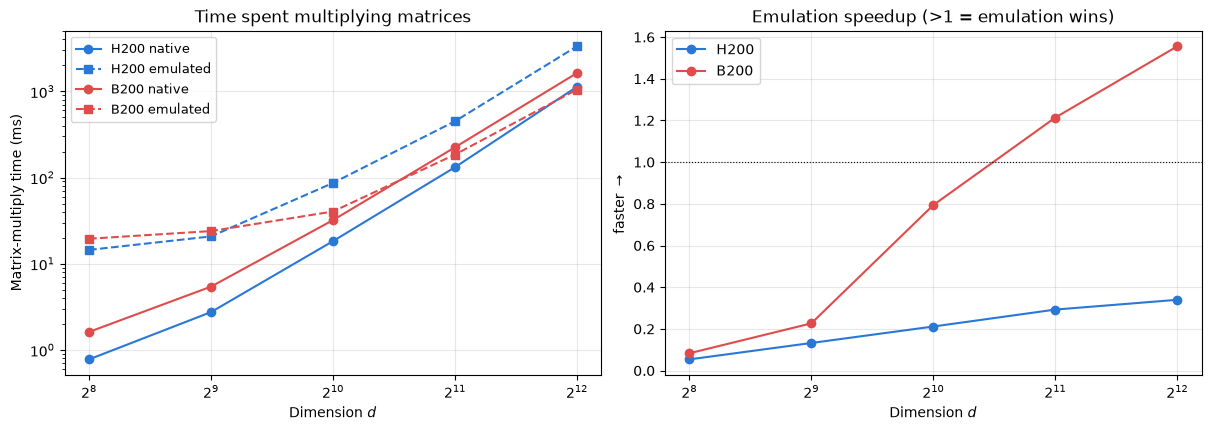

In [21]:
GEMM_OP = 'custom-call.1'
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

for gpu, c in [('gpu_h200', '#2a78d6'), ('gpu_b200', '#e04b4b')]:
    dd = [d for d in dims_of(f'{gpu}_ozaki') if d >= 256]
    nat = np.array([op_table(f'{gpu}_all_cmdbuf_off', 'cayley', d).get(GEMM_OP, np.nan) for d in dd])
    emu = np.array([op_table(f'{gpu}_ozaki', 'cayley', d).get(GEMM_OP, np.nan) for d in dd])
    axs[0].plot(dd, nat, 'o-', color=c, label=f'{gpu[4:].upper()} native')
    axs[0].plot(dd, emu, 's--', color=c, label=f'{gpu[4:].upper()} emulated')
    axs[1].plot(dd, nat / emu, 'o-', color=c, label=gpu[4:].upper())

axs[0].set_xscale('log', base=2); axs[0].set_yscale('log')
axs[0].set_xlabel('Dimension $d$'); axs[0].set_ylabel('Matrix-multiply time (ms)')
axs[0].set_title('Time spent multiplying matrices'); axs[0].legend(fontsize=9); axs[0].grid(alpha=0.3)
axs[1].axhline(1.0, color='k', lw=0.8, ls=':')
axs[1].set_xscale('log', base=2); axs[1].set_xlabel('Dimension $d$')
axs[1].set_ylabel('faster $\\rightarrow$')
axs[1].set_title('Emulation speedup (>1 = emulation wins)'); axs[1].legend(); axs[1].grid(alpha=0.3)
plt.show()

**H200 has strong double-precision hardware, so emulating it is 2.9x slower.
B200's is cut back, so emulation makes the multiply 1.6x faster.**

### But on B200 the win never reaches the clock

The GPU finishes its work sooner and then waits. Emulation pauses the GPU twice
per matrix multiply - 219 pauses longer than 1 ms, adding up to 482 ms of doing
nothing. Native has none at all.

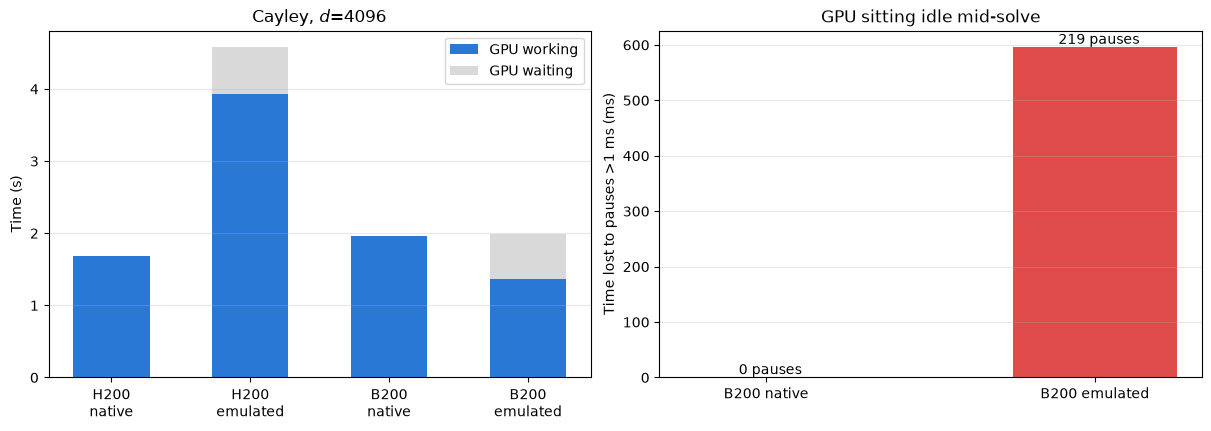

H200 native      wall= 1.690s   GPU working= 1.688s
H200 emulated    wall= 4.580s   GPU working= 3.934s
B200 native      wall= 1.960s   GPU working= 1.955s
B200 emulated    wall= 1.988s   GPU working= 1.370s


In [22]:
d = 4096
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

labels = ['H200\nnative', 'H200\nemulated', 'B200\nnative', 'B200\nemulated']
sets = ['gpu_h200_all_cmdbuf_off', 'gpu_h200_ozaki',
        'gpu_b200_all_cmdbuf_off', 'gpu_b200_ozaki']
busy = np.array([med(s, 'cayley', d, 'device_busy_ns') / 1e9 for s in sets])
wall = np.array([med(s, 'cayley', d) for s in sets])
x = np.arange(len(sets))
axs[0].bar(x, busy, 0.55, label='GPU working', color='#2a78d6')
axs[0].bar(x, np.maximum(wall - busy, 0), 0.55, bottom=busy,
           label='GPU waiting', color='#d9d9d9')
axs[0].set_xticks(x); axs[0].set_xticklabels(labels)
axs[0].set_ylabel('Time (s)'); axs[0].set_title(f'Cayley, $d$={d}')
axs[0].legend(); axs[0].grid(alpha=0.3, axis='y')

for ds, lab, c in [('gpu_b200_all_cmdbuf_off', 'B200 native', '#2a78d6'),
                   ('gpu_b200_ozaki', 'B200 emulated', '#e04b4b')]:
    tot = kern(ds, 'cayley', d, 'gaps_gt1ms_ms')
    n = kern(ds, 'cayley', d, 'n_gaps_gt1ms')
    axs[1].bar(lab, tot, 0.5, color=c)
    axs[1].text(lab, tot, f'  {n:.0f} pauses', ha='center', va='bottom')
axs[1].set_ylabel('Time lost to pauses >1 ms (ms)')
axs[1].set_title('GPU sitting idle mid-solve'); axs[1].grid(alpha=0.3, axis='y')
plt.show()

for s, l in zip(sets, labels):
    print(f'{l.replace(chr(10)," "):16s} wall={med(s,"cayley",d):6.3f}s   GPU working={med(s,"cayley",d,"device_busy_ns")/1e9:6.3f}s')

On B200 emulation saves ~600 ms of GPU work and gives back ~480 ms as waiting,
so the wall clock barely moves (1.960 s -> 1.988 s). The pauses land right after
the range-scanning kernels, which is consistent with the scale factors having to
go back to the CPU before the next step can be queued - though the trace shows
only that the GPU is idle, not what the CPU is doing during that time.

**Bottom line: not worth enabling for this workload on either card.**

## 5. A bug this analysis uncovered

The breakdown script used to split each trace into **solving the ODE** and
**everything after it**, and it found the split point by scanning for the first
operation whose name looked like after-the-ODE work. One of the names it looked
for was `custom-call` - XLA's generic label for "hand this off to an external
library". Matrix multiplication is handed off to cuBLAS, so **matrix multiplies
are also called `custom-call`**.

So it found the first matrix multiply, ~4.5 ms into a ~1700 ms run - inside the
first ODE step - and concluded the ODE had already finished.

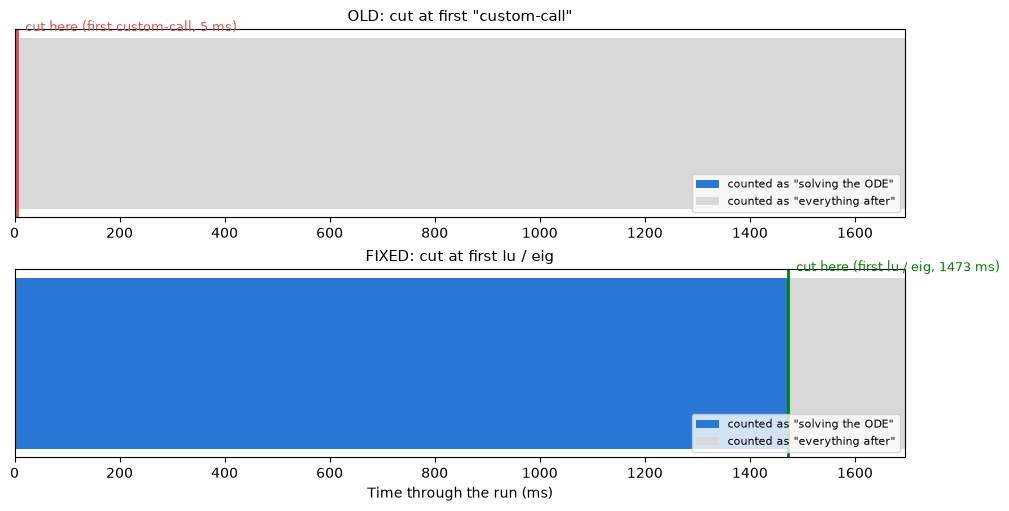

OLD  : ODE =     4.3 ms,  everything after =  1684.3 ms
FIXED: ODE =  1467.3 ms,  everything after =   220.9 ms


In [23]:
ds, d = 'gpu_h200_all_cmdbuf_off', 4096
wrong_t = kern(ds, 'cayley', d, 'first_gemm_ms')
right_t = kern(ds, 'cayley', d, 'first_post_ms')
span = kern(ds, 'cayley', d, 'span_ms')

fig, axs = plt.subplots(2, 1, figsize=(10, 5), constrained_layout=True)
for ax, cut, ct, lab, c in [(axs[0], wrong_t, 'first custom-call', 'OLD: cut at first "custom-call"', '#e04b4b'),
                            (axs[1], right_t, 'first lu / eig', 'FIXED: cut at first lu / eig', '#008300')]:
    ax.barh(0, cut, color='#2a78d6', label='counted as "solving the ODE"')
    ax.barh(0, span - cut, left=cut, color='#d9d9d9', label='counted as "everything after"')
    ax.axvline(cut, color=c, lw=2)
    ax.text(cut, 0.45, f'  cut here ({ct}, {cut:.0f} ms)', color=c, va='center', fontsize=9)
    ax.set_xlim(0, span); ax.set_yticks([]); ax.set_title(lab, fontsize=11)
    ax.legend(loc='lower right', fontsize=8)
axs[1].set_xlabel('Time through the run (ms)')
plt.show()

for lab, path in [('OLD  ', 'split_at_gemm'), ('FIXED', 'split_at_post')]:
    a = kern(ds, 'cayley', d, f'{path}.before_ms')
    b = kern(ds, 'cayley', d, f'{path}.after_ms')
    print(f'{lab}: ODE = {a:7.1f} ms,  everything after = {b:7.1f} ms')

The old split reported the ODE taking ~4 ms and the leftover ~1700 ms - backwards.

**Why it only showed up when it did.** While cuBLAS calls were being bundled into
command buffers (section 3), the matrix multiplies were labelled
`command_buffer_32` rather than `custom-call`, so the scan never matched them and
happened to get the right answer. Turning that bundling off exposed them under
their real name.

**The fix**, twice over: split only on `lu`, `eig`, `triangular-solve` (operations
that cannot occur during an explicit Runge-Kutta step), and raise if the stretch
labelled "ODE" contains no matrix multiply at all. Section 6 then replaces the
heuristic entirely with the compiler's own phase assignment.

---
## 6. Propagator vs diagonalisation, straight from the compiler

`solvers.py` wraps each stage in `jax.named_scope`, and `profiling.phase_map()`
reads that tagging back out of the compiled HLO. Every op is then assigned to a
phase by the compiler rather than by guessing from its name or its position in
the timeline - which matters because `dot_general` and `while` genuinely occur
in *both* phases.

Rows produced before the markers existed have no phase data; those are skipped
rather than guessed at, so this section fills in as runs are repeated.

In [24]:
PHASES = ['PHASE_PROPAGATOR', 'PHASE_DIAGONALIZATION', 'unassigned']
PH_COLOR = {'PHASE_PROPAGATOR': '#2a78d6', 'PHASE_DIAGONALIZATION': '#e04b4b',
            'unassigned': '#d9d9d9'}
PH_LABEL = {'PHASE_PROPAGATOR': 'propagator (ODE)',
            'PHASE_DIAGONALIZATION': 'diagonalisation',
            'unassigned': 'unassigned'}

def phase_rows(ds):
    """[(solver, d, phase_self_ns)] for rows that carry the compiler's split."""
    out = []
    for s in data[ds]:
        for d, rows in sorted(data[ds][s].items()):
            vals = [r['phase_self_ns'] for r in rows if r.get('phase_self_ns')]
            if vals:
                agg = {p: float(np.median([v.get(p, 0.0) for v in vals])) for p in PHASES}
                out.append((s, d, agg))
    return out

found = {ds: phase_rows(ds) for ds in devices}
have = {ds: v for ds, v in found.items() if v}
for ds in devices:
    n = len(found[ds])
    print(f'  {ds:26s} {n:3d} (solver, d) combination(s) with phase data'
          + ('' if n else '   <- rerun to populate'))

  cpu                          0 (solver, d) combination(s) with phase data   <- rerun to populate
  gpu_h200_nocmdbuf            0 (solver, d) combination(s) with phase data   <- rerun to populate
  gpu_h200_cmdbuf              0 (solver, d) combination(s) with phase data   <- rerun to populate
  gpu_h200_all_cmdbuf_off      0 (solver, d) combination(s) with phase data   <- rerun to populate
  gpu_h200_ozaki               0 (solver, d) combination(s) with phase data   <- rerun to populate
  gpu_b200_all_cmdbuf_off      0 (solver, d) combination(s) with phase data   <- rerun to populate
  gpu_b200_ozaki               0 (solver, d) combination(s) with phase data   <- rerun to populate


In [25]:
if not have:
    print('No rows carry phase data yet. Re-run one job per device to populate '
          '(see section 6 text), then re-run this notebook.')
else:
    entries = [(ds, s, d, agg) for ds, rows in have.items() for s, d, agg in rows]
    fig, ax = plt.subplots(figsize=(max(6, 1.4 * len(entries) + 3), 4.2),
                           constrained_layout=True)
    x = np.arange(len(entries))
    bottom = np.zeros(len(entries))
    for p in PHASES:
        vals = np.array([e[3].get(p, 0.0) / 1e6 for e in entries])
        if vals.sum() == 0:
            continue
        ax.bar(x, vals, 0.6, bottom=bottom, color=PH_COLOR[p], label=PH_LABEL[p],
               edgecolor='white')
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels([f'{ds.replace("gpu_","").replace("_"," ")}\n{s} d={d}'
                        for ds, s, d, _ in entries], fontsize=8, rotation=0)
    ax.set_ylabel('Device time (ms)')
    ax.set_title('Where the device time goes, per the compiler')
    ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
    plt.show()

    for ds, s, d, agg in entries:
        tot = sum(agg.values()) or 1.0
        parts = '  '.join(f'{PH_LABEL[p]}={agg.get(p,0)/1e6:8.2f} ms ({100*agg.get(p,0)/tot:4.1f}%)'
                          for p in PHASES)
        print(f'{ds:24s} {s:9s} d={d:5d}  {parts}')

No rows carry phase data yet. Re-run one job per device to populate (see section 6 text), then re-run this notebook.


In [26]:
# Kernel-level categories *within* each phase (GPU only - needs stream lines).
kp = [(ds, s, d, r['kernels']['phases'])
      for ds in devices for s in data[ds] for d, rows in sorted(data[ds][s].items())
      for r in rows if (r.get('kernels') or {}).get('phases')]

if not kp:
    print('No GPU rows carry the per-phase kernel breakdown yet.')
else:
    ds, s, d, ph = kp[0]
    print(f'{ds}  {s}  d={d}\n')
    for phase in PHASES:
        blk = ph.get(phase)
        if not blk or not blk.get('n'):
            continue
        print(f'  {PH_LABEL.get(phase, phase)}: {blk["n"]} kernels, {blk["ms"]:.1f} ms')
        for cat, ms in sorted(blk.get('by_category', {}).items(), key=lambda kv: -kv[1]):
            print(f'      {ms:9.2f} ms  {100*ms/blk["ms"]:5.1f}%  {cat}')
        print()

No GPU rows carry the per-phase kernel breakdown yet.


---
## Caveats worth remembering when reading the panels above

- `device_busy_ns` and the op breakdowns come from the **traced** run, while
  `t_total` comes from the untraced one. Tracing inflates per-op times, so
  `device_busy_ns / t_total` is only meaningful for $d \gtrsim 128$; below that
  it exceeds 1 on CPU.
- Device time is **not comparable across command-buffer variants**. Under
  `+WHILE` the loop is one CUDA graph and the profiler reports graph launch cost,
  so `gpu_h200_cmdbuf` op times are launch costs, not kernel costs. Compare
  `t_total` across variants; compare op times only within one.
- On GPU, `mem_total` (host RSS) is dominated by a ~3.8 GB constant from CUDA
  initialisation. `mem_gpu` is the meaningful memory signal there.
- Both diagonalisation routines run far below peak (`eig` 2.2%, `eigh` 4.4% at
  $d$=4096), so neither runtime has reached its $d^3$ asymptote yet.